# Initialization, Imports

In [1]:
import pandas as pd

import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from itertools import combinations

/home/wjh/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_events = pd.read_pickle("./data/CAC_matched.pkl")
df_names = pd.read_parquet("./data/authority_file_cac_alma.parquet")
df_names_cac = df_names.dropna(subset="cac_id")
cac_id_dict = dict(zip(df_names_cac.cac_id.to_list(), df_names_cac.final_id))

df_events["date_start"] = df_events["date_start"].apply(lambda x:x.date())
df_events["date_end"] = df_events["date_end"].apply(lambda x:x.date())

In [3]:
df_events

,person_id,event_place,event_place_parent,event_place_id,event_place_parent_id,date_start,date_end,event_metadata
0,2033185,Kolegium Większe {Uniwersytetu Krakowskiego},Uniwersytet Krakowski (Akademia Krakowska),7613.0,8309.0,1517-04-23,1534-11-27,"{'position': 'kolegiat', 'event_type': 'trwani..."
1,2009152,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1629-04-23,1629-10-15,"{'position': 'dziekan (wydziału)', 'event_type..."
2,2001785,województwo bełskie,województwo bełskie,8372.0,8372.0,1640-10-16,1641-04-22,"{'position': 'wojewodzic', 'event_type': 'trwa..."
4,1995358,Kolegium Większe {Uniwersytetu Krakowskiego},Uniwersytet Krakowski (Akademia Krakowska),7613.0,8309.0,1444-08-07,1444-08-07,"{'position': 'kolegiat', 'event_type': 'trwani..."
5,1994447,Kolegium Większe {Uniwersytetu Krakowskiego},Uniwersytet Krakowski (Akademia Krakowska),7613.0,8309.0,1432-04-23,1432-04-23,"{'position': 'prepozyt (kolegium)', 'event_typ..."
...,...,...,...,...,...,...,...,...
5144,2031231,Uniwersytet Krakowski (Akademia Krakowska),Uniwersytet Krakowski (Akademia Krakowska),8309.0,8309.0,1522-02-01,1522-02-28,"{'degree_type': 'student', 'event_type': 'trwa..."
5145,2032051,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1756-10-16,1757-04-22,"{'degree_type': 'bakałarz', 'event_type': 'pos..."
5146,2032538,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1778-04-03,1778-04-03,"{'degree_type': 'magister', 'event_type': 'pos..."
5147,2032538,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1779-03-19,1779-03-19,"{'degree_type': 'magister', 'event_type': 'pos..."


In [4]:
df_names

,final_id,alma_born,alma_died,first_polish_pub,cac_id,alma_name
0,0,NaN,NaN,None,NaN,A. M.
1,1,1604.0,1691.0,None,NaN,"Abelly, Louis (1604-1691)"
2,2,1606.0,1664.0,None,NaN,"Ablancourt, Nicolas Perrot d' (1606-1664)"
3,3,1600.0,1700.0,None,2014948.0,"Abrek, Andrzej (16..-1700)"
4,4,NaN,1656.0,None,2014945.0,"Abrek, Andrzej (?-1656)"
...,...,...,...,...,...,...
3975,3697,1600.0,1799.0,None,2003875.0,"Celejowicz, Maciej Paweł (16..-17..)"
3976,3698,1544.0,1617.0,None,NaN,"Botero, Giovanni (1540-1617)"
3977,3698,1544.0,1617.0,None,NaN,"Botero, Giovanni (1544-1617)"
3978,3699,NaN,NaN,None,NaN,Aristoteles (384-322 a.C.)


In [5]:
publications_df = pd.read_pickle("./data/ALMA_matched.pkl")
publications_df = publications_df[publications_df["all_names_final_id"].apply(lambda x: len(x) > 1)]

In [6]:
publications_df

,ALMA_id,autors_list,title,subtitle,publication_city,date_start,date_end,record_type,all_names,all_names_final_id,contributing_persons,contributing_organizations,genre,subjects_people,subjects_topics,subjects_places
208,991000470979705067,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",na rok ... [...] /,[a: Polska | d: Kraków.],1806-01-01,1832-12-31,Tekst,"[Koch, Rudolf Bogumił (1771-post 1854), Ryszko...","(1362, 1283, 2604)","[(Ryszkowski, Franciszek Ksawery (1746-1809), ...",[(Drukarnia Antoniego Gröbla Wdowy i Sukcesoró...,"[Kalendarze, Kalendarze]",None,None,None
217,991000474089705067,"[Sienkiewicz, Piotr (czynny 1685-1701)]","Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...","Dum A [...] Joanne De Małachowice Małachowski,...",[a: Polska | d: Kraków.],1688-03-18,1690-03-18,Tekst,"[Schedel, Mikołaj Aleksander (1644-1708), Sien...","(2667, 2996, 2734)","[(Schedel, Mikołaj Aleksander (1644-1708), [Dr...",None,None,None,None,None
226,991000475869705067,"[Woysznarowicz, Kazimierz Jan ( -1680)]",Orator Politiczny Weselnym y Pogrzebowym Słvzą...,None,[a: Polska | d: Kraków.],1646-01-01,1648-12-31,Tekst,"[Woysznarowicz, Kazimierz Jan ( -1680), Cezary...","(2633, 3361, 3641)","[(Sapieha, Jan Ferdynand (1629-1659), [Adr. de...",None,"[Mowy weselne, Przemówienia polskie, Mowy pogr...",None,None,None
281,991000493069705067,"[Skarszewski, Wojciech (1742-1827)]",Skutki Nowey Filozofii Spokoyności Kraiowey gr...,None,[a: Polska | d: Warszawa.],1791-01-01,1793-12-31,Tekst,"[Skarszewski, Wojciech (1742-1827), Gröll, Mic...","(990, 2767)","[(Gröll, Michał (1722-1798), [Księg.])]",None,None,None,None,None
296,991000497659705067,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767)]",Auspicia Sandomiriensis Palatinæ Curulis Secun...,None,[a: Polska | d: Kraków.],1750-08-22,1752-08-22,Tekst,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767),...","(170, 3267)","[(Wielopolski, Jan (?-1773), [Adr. ded.])]","[(Drukarnia Akademicka (Kraków), None)]",None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788191,991008986109705067,"[Trigault, Nicolas (1577-1628)]","Nowiny Abo Dzieie dwuletnie Chinenskie, /",None,[a: Polska | d: Kraków.],1614-01-01,1616-12-31,None,"[Januszowski, Jan (1550-1613), Jędrzejowczyk, ...","(3681, 2407, 3378, 3126, 1207)","[(Jędrzejowczyk, Maciej (15..-1638), None), (J...",None,None,None,None,None
788199,991008989789705067,"[Warzyński, Andrzej Paweł (16..-16..)]",Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,None,[a: Polska | d: Kraków.],1680-07-20,1682-07-20,None,"[Cezary, Franciszek (ok. 1660-1724), Warzyński...","(368, 273, 3226)","[(Bryszkiewicz, Jacek (16..-1689), [Adr. ded.]...",None,None,None,None,None
790406,991011913959705067,"[Jurkowski, Jan (1580-1635)]","""Tragedya o polskim Scylurusie""",None,None,1889-01-01,1889-12-31,Tekst,"[Jurkowski, Jan (1580-1635), Pauli, Żegota (18...","(2212, 1260)","[(Pauli, Żegota (1814-1895), [Kopista])]",None,None,None,None,None
790498,991011937969705067,"[Władysławski, Gabriel (ca 1570-1631)]","""Intentio erectionis certarum lecturarum in Ac...",None,None,1672-01-01,1672-12-31,Tekst,"[Muczkowski, Józef (1860-1943), Brożek, Jan (1...","(1954, 3406, 263)","[(Muczkowski, Józef (1860-1943), [Właściciel])...",None,None,None,None,None


Provided topics are sparse and chaotic and often unique and with varying granularity

In [7]:
print(set(x for lst in publications_df["subjects_topics"].dropna() for x in lst))

{'Bractwa szkaplerzne', 'Geografia historyczna', 'Duchowość zakonna', 'Grób Jezusa Chrystusa (Jerozolima)', 'List pasterski', 'Metodologia', 'Język francuski', 'Kalendarz liturgiczny', 'Futurologia', 'Chocim, Bitwa (1621)', 'Grzech', 'Uzdrowiska', 'Protestantyzm', 'Kazania na rok liturgiczny', 'Katecheza', 'Wielka wojna z Zakonem Krzyżackim (1409-1411)', 'Sztuka wojenna', 'Pisarze polscy', 'Sól kamienna', 'Charakter narodowy hiszpański.', 'Komety', 'Epistolografia', 'Medycyna', 'Żałoba', 'Szkotyzm', 'Starożytność', 'Gozdawa (herb)', 'Mistyka', 'Język łaciński', 'Roch (herb)', 'Liturgia katolicka', 'Kalendarz (rachuba czasu)', 'Ciepłolecznictwo', 'Kościół a państwo', 'Trzęsienie ziemi', 'Geografia fizyczna', 'Prawo cywilne', 'Święto (liturgia katolicka)', 'Teologia dogmatyczna', 'Etyka chrześcijańska', 'Kuczaba (herb)', 'Wpływ i recepcja', 'Krzywica', 'Promocja doktorska', 'Religia grecka', 'Panegiryk', 'Historia', 'Wersyfikacja', 'Uroczystości żałobne', 'Prawo magdeburskie', 'Prawo sas

# Make a replacement column for subjects or topics, using title column, embedding and clustering

First prepare strings to embed, and embedding

In [8]:
publications_df["topic_text"] = (
    publications_df[["title", "subtitle"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Embedding

In [9]:
model = SentenceTransformer("sentence-transformers/distiluse-base-multilingual-cased-v1")

embeddings = model.encode(
    publications_df["topic_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches: 100%|██████████| 189/189 [02:56<00:00,  1.07it/s]


Dimensionality reduction

In [10]:
pca = PCA(
    n_components=0.97, # keep 97% variance
    random_state=42
)

embeddings_pca = pca.fit_transform(embeddings)

print(
    f"{embeddings.shape[1]} -> "
    f"{embeddings_pca.shape[1]} dimensions"
)

512 -> 282 dimensions


Clustering

In [11]:
bic_scores = []
models = []

for k in range(3, 20):
    print(k)
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42,
        max_iter=200,
        n_init=2,
    ).fit(embeddings_pca)
    bic_current = gmm.bic(embeddings_pca)
    bic_scores.append(bic_current)
    print(bic_current)
    models.append(gmm)

best_k = np.argmin(bic_scores) + 3
best_gmm = models[np.argmin(bic_scores)]

publications_df["topic_cluster"] = best_gmm.predict(embeddings_pca)
probs = best_gmm.predict_proba(embeddings_pca)
publications_df["cluster_confidence"] = probs.max(axis=1)
publications_df["cluster_probs"] = list(probs)
print(f"Best k={best_k}")

3
-6579284.94813722
4
-6583036.803631996
5
-6585186.024117005
6
-6586256.74643307
7
-6585053.260375111
8
-6586721.100611097
9
-6585482.966970131
10
-6585206.119461976
11
-6583917.857403041
12
-6612557.735236683
13
-6611960.2132900525
14
-6588208.52252018
15
-6587545.391320619
16
-6604640.252186488
17
-6603323.977188099
18
-6570828.563395766
19
-6599001.804632728
Best k=12


## Checks of quality of topic assignments and embeddings

Components are well separated, only tail is more ambiguous

In [12]:
log_probs = best_gmm._estimate_weighted_log_prob(embeddings_pca)

top2 = np.sort(log_probs, axis=1)[:, -2:]

gap = top2[:, 1] - top2[:, 0]

print(np.percentile(gap, [5, 25, 50, 75, 95]))

# most samples have a positive gap (with median near 7.33), so for many points the top component is substantially more likely than the second-best

[ 1.5732605   4.39047241  7.33312988 11.78912354 25.04745483]


In [13]:
entropy = -(probs * np.log(probs + 1e-12)).sum(axis=1)

print(entropy, np.log(best_k)) # Smaller values are more certain, mostly values are small, they are smaller than ln(K) which means they are reasonable

[4.0173594e-02 6.4469719e-01 2.5789944e-02 ... 2.8240045e-17 2.9680697e-07
 6.2703353e-01] 2.4849066497880004


Check hard and soft component sizes

In [14]:
labels = best_gmm.predict(embeddings_pca)
probs = best_gmm.predict_proba(embeddings_pca)

summary = pd.DataFrame({
    "component": range(best_gmm.n_components),
    "weight": best_gmm.weights_,
    "soft_size": probs.sum(axis=0),
    "hard_size": np.bincount(
        labels,
        minlength=best_gmm.n_components
    )
})

summary.sort_values("soft_size", ascending=False)
# Some components are smaller, but most comonents are of reasonable sizes

,component,weight,soft_size,hard_size
6,6,0.180218,1087.429077,1082
2,2,0.166448,1005.370239,1008
10,10,0.148646,902.044067,903
9,9,0.148174,894.045776,898
1,1,0.111909,675.713867,675
8,8,0.070717,427.506470,426
7,7,0.070804,424.557800,425
3,3,0.031105,187.678528,187
5,5,0.027615,166.736771,167
0,0,0.026976,162.910049,163


Check dataframe

In [15]:
publications_df

,ALMA_id,autors_list,title,subtitle,publication_city,date_start,date_end,record_type,all_names,all_names_final_id,contributing_persons,contributing_organizations,genre,subjects_people,subjects_topics,subjects_places,topic_text,topic_cluster,cluster_confidence,cluster_probs
208,991000470979705067,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",na rok ... [...] /,[a: Polska | d: Kraków.],1806-01-01,1832-12-31,Tekst,"[Koch, Rudolf Bogumił (1771-post 1854), Ryszko...","(1362, 1283, 2604)","[(Ryszkowski, Franciszek Ksawery (1746-1809), ...",[(Drukarnia Antoniego Gröbla Wdowy i Sukcesoró...,"[Kalendarze, Kalendarze]",None,None,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",6,0.993430,"[5.285184e-34, 4.1358254e-12, 7.3104147e-22, 1..."
217,991000474089705067,"[Sienkiewicz, Piotr (czynny 1685-1701)]","Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...","Dum A [...] Joanne De Małachowice Małachowski,...",[a: Polska | d: Kraków.],1688-03-18,1690-03-18,Tekst,"[Schedel, Mikołaj Aleksander (1644-1708), Sien...","(2667, 2996, 2734)","[(Schedel, Mikołaj Aleksander (1644-1708), [Dr...",None,None,None,None,None,"Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...",9,0.654377,"[4.50906e-14, 2.469368e-28, 0.34561184, 4.8474..."
226,991000475869705067,"[Woysznarowicz, Kazimierz Jan ( -1680)]",Orator Politiczny Weselnym y Pogrzebowym Słvzą...,None,[a: Polska | d: Kraków.],1646-01-01,1648-12-31,Tekst,"[Woysznarowicz, Kazimierz Jan ( -1680), Cezary...","(2633, 3361, 3641)","[(Sapieha, Jan Ferdynand (1629-1659), [Adr. de...",None,"[Mowy weselne, Przemówienia polskie, Mowy pogr...",None,None,None,Orator Politiczny Weselnym y Pogrzebowym Słvzą...,9,0.996041,"[7.619563e-24, 3.8108838e-28, 1.8057952e-27, 8..."
281,991000493069705067,"[Skarszewski, Wojciech (1742-1827)]",Skutki Nowey Filozofii Spokoyności Kraiowey gr...,None,[a: Polska | d: Warszawa.],1791-01-01,1793-12-31,Tekst,"[Skarszewski, Wojciech (1742-1827), Gröll, Mic...","(990, 2767)","[(Gröll, Michał (1722-1798), [Księg.])]",None,None,None,None,None,Skutki Nowey Filozofii Spokoyności Kraiowey gr...,1,1.000000,"[0.0, 1.0, 0.0, 4.928726e-24, 0.0, 0.0, 0.0, 5..."
296,991000497659705067,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767)]",Auspicia Sandomiriensis Palatinæ Curulis Secun...,None,[a: Polska | d: Kraków.],1750-08-22,1752-08-22,Tekst,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767),...","(170, 3267)","[(Wielopolski, Jan (?-1773), [Adr. ded.])]","[(Drukarnia Akademicka (Kraków), None)]",None,None,None,None,Auspicia Sandomiriensis Palatinæ Curulis Secun...,2,0.997196,"[7.327964e-18, 4.640344e-18, 0.9971963, 2.6306..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788191,991008986109705067,"[Trigault, Nicolas (1577-1628)]","Nowiny Abo Dzieie dwuletnie Chinenskie, /",None,[a: Polska | d: Kraków.],1614-01-01,1616-12-31,None,"[Januszowski, Jan (1550-1613), Jędrzejowczyk, ...","(3681, 2407, 3378, 3126, 1207)","[(Jędrzejowczyk, Maciej (15..-1638), None), (J...",None,None,None,None,None,"Nowiny Abo Dzieie dwuletnie Chinenskie, /",1,1.000000,"[0.0, 1.0, 0.0, 1.8927163e-13, 0.0, 7.760808e-..."
788199,991008989789705067,"[Warzyński, Andrzej Paweł (16..-16..)]",Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,None,[a: Polska | d: Kraków.],1680-07-20,1682-07-20,None,"[Cezary, Franciszek (ok. 1660-1724), Warzyński...","(368, 273, 3226)","[(Bryszkiewicz, Jacek (16..-1689), [Adr. ded.]...",None,None,None,None,None,Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,2,1.000000,"[3.0470523e-21, 4.309757e-20, 1.0, 4.5152718e-..."
790406,991011913959705067,"[Jurkowski, Jan (1580-1635)]","""Tragedya o polskim Scylurusie""",None,None,1889-01-01,1889-12-31,Tekst,"[Jurkowski, Jan (1580-1635), Pauli, Żegota (18...","(2212, 1260)","[(Pauli, Żegota (1814-1895), [Kopista])]",None,None,None,None,None,"""Tragedya o polskim Scylurusie""",1,1.000000,"[0.0, 1.0, 0.0, 8.403113e-28, 0.0, 0.0, 0.0, 3..."
790498,991011937969705067,"[Władysławski, Gabriel (ca 1570-1631)]","""Inten

In [16]:
publications_df["cluster_probs"]

208       [5.285184e-34, 4.1358254e-12, 7.3104147e-22, 1...
217       [4.50906e-14, 2.469368e-28, 0.34561184, 4.8474...
226       [7.619563e-24, 3.8108838e-28, 1.8057952e-27, 8...
281       [0.0, 1.0, 0.0, 4.928726e-24, 0.0, 0.0, 0.0, 5...
296       [7.327964e-18, 4.640344e-18, 0.9971963, 2.6306...
                                ...                        
788191    [0.0, 1.0, 0.0, 1.8927163e-13, 0.0, 7.760808e-...
788199    [3.0470523e-21, 4.309757e-20, 1.0, 4.5152718e-...
790406    [0.0, 1.0, 0.0, 8.403113e-28, 0.0, 0.0, 0.0, 3...
790498    [0.0, 1.0, 1.51942e-35, 2.496556e-17, 0.0, 0.0...
792009    [2.1501732e-23, 2.2497594e-19, 0.12515704, 1.9...
Name: cluster_probs, Length: 6039, dtype: object

Visualizing probability vectors, to see whether they are appropriate

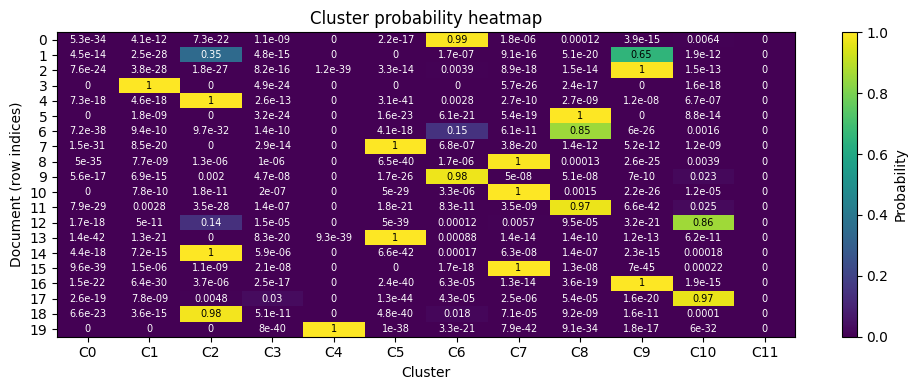

In [17]:
# build matrix
# rows are documents, cols are clusters
probs = np.vstack(publications_df["cluster_probs"].head(20).values)  # shape (n_docs, n_clusters)

fig, ax = plt.subplots(figsize=(10, max(4, probs.shape[0]*0.2)))
im = ax.imshow(probs, aspect="auto", cmap="viridis", interpolation="nearest")

# labels
ax.set_xlabel("Cluster")
ax.set_ylabel("Document (row indices)")
ax.set_title("Cluster probability heatmap")

# use document indices as y ticks
y_idx = np.arange(probs.shape[0])
ax.set_yticks(y_idx)

ax.set_xticks(np.arange(probs.shape[1]))
ax.set_xticklabels([f"C{c}" for c in range(probs.shape[1])])

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Probability")

# annotate values
for i in range(probs.shape[0]):
    for j in range(probs.shape[1]):
        val = probs[i, j]
        ax.text(j, i, f"{val:.2g}", ha="center", va="center",
                color="black" if val > 0.5*probs.max() else "white", fontsize=7)

plt.tight_layout()
plt.show()


## Check what the clusters contain

Check closest document to centroid

In [18]:
cluster_names = {}

for c in np.unique(publications_df["topic_cluster"]):
    idx = publications_df["topic_cluster"] == c
    cluster_embs = embeddings[idx] # On purpose not PCA
    
    centroid = cluster_embs.mean(axis=0)
    
    # find closest document to centroid
    sims = cluster_embs @ centroid
    best_doc = publications_df.loc[idx].iloc[np.argmax(sims)]["topic_text"]
    
    cluster_names[c] = best_doc[:40] # truncate for readability

cluster_names

{np.int64(0): 'Coronamentvm Veris Laureati Nouo eruditæ',
 np.int64(1): 'Srebrne Złotey Nałęczy Zadziergnienie, w',
 np.int64(2): 'Æcumenicum Ecclesiæ Vniversalis Conciliu',
 np.int64(3): 'Ivdex Ecclesiasticvs, Potestate Ligandi ',
 np.int64(4): 'Archiwum Macieja Sołtyka.',
 np.int64(5): 'Zguba Oyczyzny stacya /',
 np.int64(6): 'Chloris Cælica B. Salomæa Regina Haliciæ',
 np.int64(7): 'Rekreacya Przy Piątkv, Bez Smvtkv: z Nay',
 np.int64(8): 'Panegyricvs [...] Poloniæ Sveciæqve Prin',
 np.int64(9): 'Olor Wąsowicianvs In Cathedram Doctorale',
 np.int64(10): 'Gregorii Macri Szepsii Pannonis ... Lavr',
 np.int64(11): 'Dykcyonarz Powszechny Medyki, Chirurgii,'}

LLM-generated cluster names

In [20]:
from ollama import ChatResponse, Client

cluster_samples = {}

for c in np.unique(publications_df["topic_cluster"]):
    idx = publications_df["topic_cluster"] == c
    cluster_embs = embeddings[idx] # On purpose not PCA
    cluster_texts = publications_df.loc[idx, "topic_text"].values

    centroid = cluster_embs.mean(axis=0)

    # similarity to centroid
    sims = cluster_embs @ centroid # since normalized embeddings

    top_idx = np.argsort(sims)[-10:] # top 100 most central docs
    cluster_samples[c] = set(cluster_texts[top_idx].tolist())

def build_prompt(texts, cluster_id):
    joined = "\n".join(f"- {t}" for t in texts)
    print(joined)

    return f"""
You are helping label a topic cluster.

Below are representative documents from one cluster:

{joined}

Task:
1. Give a short topic label (2-6 words)
2. Give a slightly longer description (1-2 sentences)

Return in JSON:
{{
  "label": "...",
  "description": "..."
}}

Do NOT write anything other than JSON.
Do NOT write fenced code blocks, only JSON.
Do NOT write multiple entries.
Write only ONE generalized, but not generic, entry with label and description, for all provided items.
In description, focus on domain (philosophy, alchemy, theology, astronomy, history, sermons, literature, medicine, geometry, architecture, ...), likely historical period if indicated, and language (old polish, latin, ...) used.
"""

def label_cluster_ollama(texts, cluster_id, model="llama3.2"):
    prompt = build_prompt(texts, cluster_id)
    client = Client(
        host='http://localhost:11434',
    )
    resp: ChatResponse = client.chat(
        model=model,
        messages=[
            {"role": "system", "content": "You are a precise topic labeling assistant."},
            {"role": "user", "content": prompt},
        ],
    )
    return resp.message.content

cluster_labels = {}

for c, texts in cluster_samples.items():
    print(f"\nLabeling cluster {c}")
    cluster_labels[c] = label_cluster_ollama(texts, c)
    print(cluster_labels[c])

cluster_labels


Labeling cluster 0
- Cornvcopiæ Honorvm & Virtvtvm. Autumnali Laureola In Viridario Iagelloniano Almæ Academiæ Crac. Nexvm Et Dum [...] XIV. Venerabiles [...] Candidati Primam Artium & Philosophiæ Lauream Prensantes. Per [...] Nicolavm Svlikowski [...] Baccalaurei renuntiarentur /
- Coronamentvm Veris Laureati Nouo eruditæ amœnitatis virore Efflorescens Virtuti, & honori VI. VV. DD. Primæ Lavreæ Candidatorvm : Dum in Alma vniuersitate Cracouiensi [...] Artium & Philosophiæ Baccalaurei [...] Renvntiarentvr [...] /
- Mvsæ Parnassides Cum nouem coronis aureo Hesperidum fructu intertextis IX. VV.DD. Primæ Lavreæ Candidatis . Dvm In Ama Vniversitate Cracouiensi, Per [...] Raphaelem Casimirvm Artenski [...] Artium & Philosophiæ Baccalaurei Ritv Solenni Renvntiarentvr [...] /
- Præmia Eruditarum Mentium ad Lyram Apollinis Instrvcta. Dum VIII. VV. DD. Primæ Laureæ Candidati [...] In Alma Vniuersitate Cracoviensi Per [...] Mathiam Pavlvm Celeiowicz Philosophiæ Doctorem & Professorem, Collegam 

{np.int64(0): '{\n  "label": "Polish Academic Awards",\n  "description": "Awards given to students of various disciplines, including philosophy, law, arts, and sciences, by the University of Cracow in Poland during the 17th century, with documents written primarily in Latin and Old Polish"',
 np.int64(1): '{\n  "label": "Historical Polish Philosophical Treatises",\n  "description": "Old Polish philosophical texts from the 17th century, primarily written in Latin, covering topics such as ethics, theology, and spirituality"',
 np.int64(2): '{\n  "label": "16th Century Polish Panegyrics",\n  "description": "These documents represent a collection of panegyric speeches delivered in honor of prominent figures, particularly monarchs and clergy, during the 16th century in Poland. They showcase the language and style of old Polish and Latin used in theological, literary, and historical contexts."',
 np.int64(3): '{\n  "label": "Medieval Christian Theology",\n  "description": "Discussions on ecc

## Compare with BERTopic

It mostly assigns outliers, which might be because the titles are rather heterogenous

In [21]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=1,
    prediction_data=True,
)

topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(
    publications_df["topic_text"].tolist(),
    embeddings
)

topic_info = topic_model.get_topic_info()
print(topic_info.head(20))

2026-06-10 22:39:22,875 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-10 22:39:41,045 - BERTopic - Dimensionality - Completed ✓
2026-06-10 22:39:41,047 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-10 22:39:42,799 - BERTopic - Cluster - Completed ✓
2026-06-10 22:39:42,804 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-10 22:39:42,975 - BERTopic - Representation - Completed ✓


    Topic  Count                                              Name  \
0      -1   1331                                    -1_de_in_na_ex   
1       0    256                  0_theologiæ_doctores_doctor_loco   
2       1    134                1_wiary_religii_christianæ_christi   
3       2    110                     2_iv_vladislai_sveciæ_poloniæ   
4       3     96     3_episcopi_cracoviensis_cracovien_szyszkowski   
5       4     78      4_philosophica_anima_aristotelis_dissertatio   
6       5     77              5_qvæstio_natura_metaphysica_physicæ   
7       6     75                        6_christi_nostri_iesv_sive   
8       7     73      7_thomas_trinitatis_prædicatorum_sanctissimæ   
9       8     72                   8_dawidow_psałterz_ustawa_droga   
10      9     70                   9_korony_paniey_polskiey_krolow   
11     10     68                        10_bene_dobrą_śmierć_libri   
12     11     66              11_cantivs_joannes_rostris_confessor   
13     12     66    

# How do the topics change through time?

In [22]:
df = publications_df.copy()
df['date_start'] = pd.to_datetime(df['date_start'], errors='coerce')

# expand cluster_probs into columns
probs = np.vstack(df['cluster_probs'].apply(lambda x: np.array(x) if x is not None else np.zeros(K)))
cols = [f'cluster_{i}' for i in range(probs.shape[1])]
probs_df = pd.DataFrame(probs, columns=cols, index=df.index)

df = pd.concat([df, probs_df], axis=1)

# time period
df['year'] = df['date_start'].dt.year
df['decade'] = (df['year'] // 10) * 10

# aggregate sums per period
agg_year = df.groupby('year')[cols].sum().sort_index()
agg_decade = df.groupby('decade')[cols].sum().sort_index()
agg_decade_prop = agg_decade.div(agg_decade.sum(axis=1), axis=0).fillna(0)
agg_year_prop = agg_year.div(agg_year.sum(axis=1), axis=0).fillna(0)

Yearly cluster shares

<Figure size 1200x600 with 0 Axes>

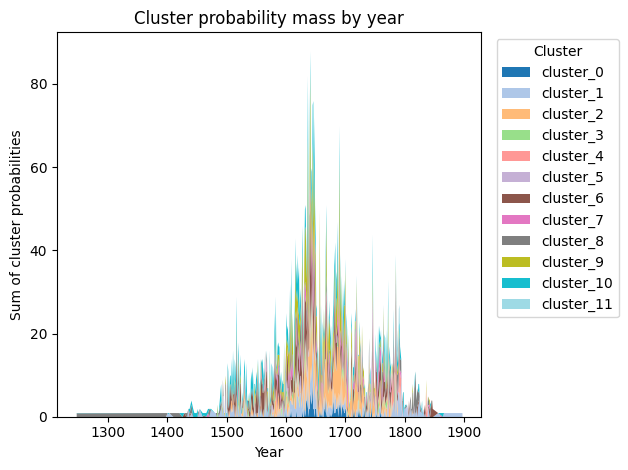

In [23]:
plt.figure(figsize=(12,6))
agg_year.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Year')
plt.ylabel('Sum of cluster probabilities')
plt.title('Cluster probability mass by year')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

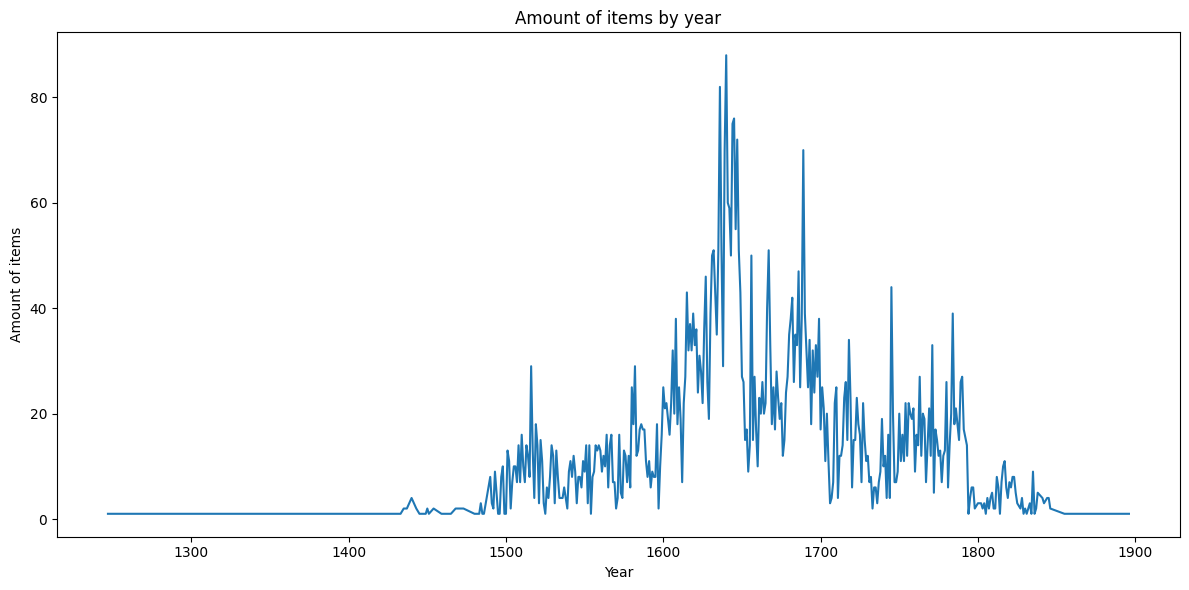

In [24]:
counts_year = df.groupby('year').size().sort_index()
plt.figure(figsize=(12,6))
counts_year.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Amount of items')
plt.title('Amount of items by year')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

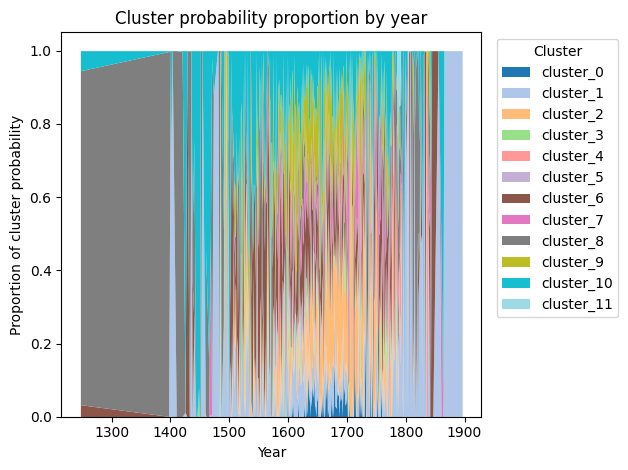

In [25]:
plt.figure(figsize=(12,6))
agg_year_prop.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Year')
plt.ylabel('Proportion of cluster probability')
plt.title('Cluster probability proportion by year')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

Cluster shares by decade

<Figure size 1200x600 with 0 Axes>

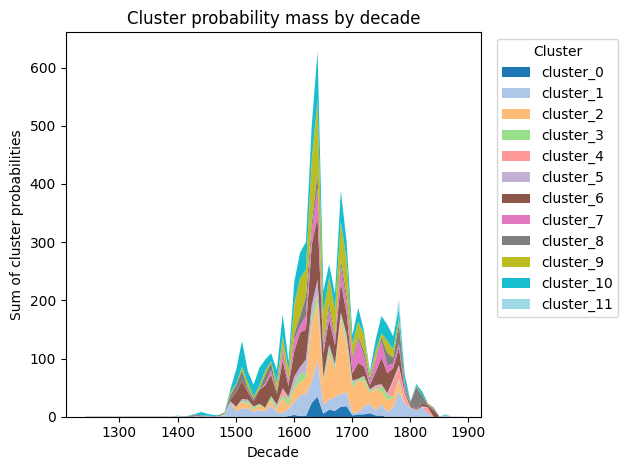

In [26]:
plt.figure(figsize=(12,6))
agg_decade.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Decade')
plt.ylabel('Sum of cluster probabilities')
plt.title('Cluster probability mass by decade')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

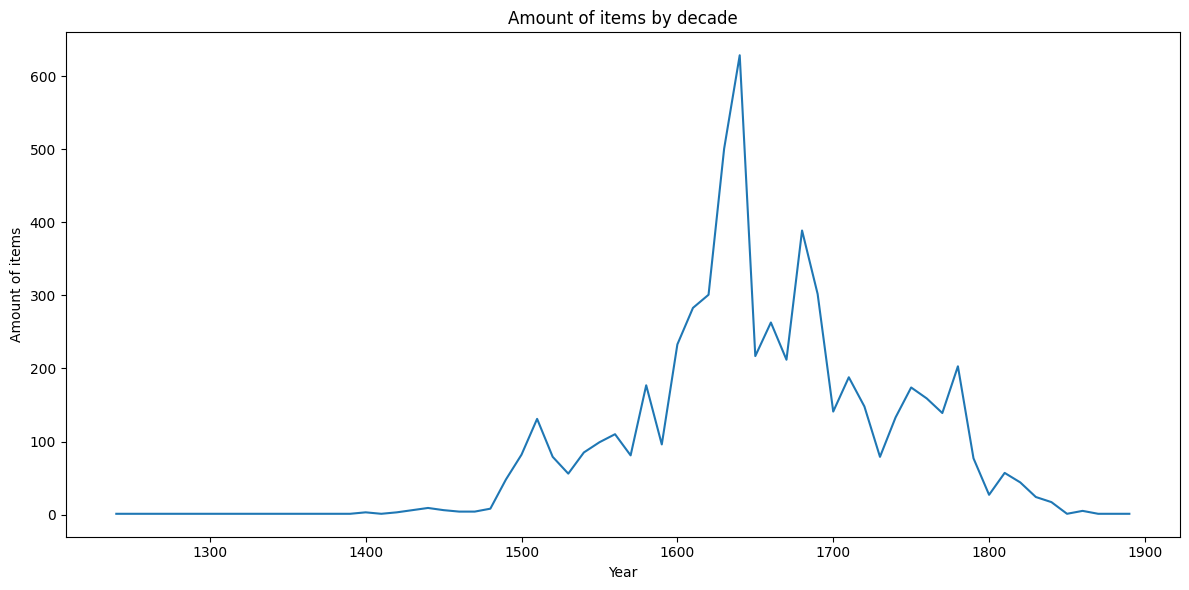

In [27]:
counts_decade = df.groupby('decade').size().sort_index()
plt.figure(figsize=(12,6))
counts_decade.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Amount of items')
plt.title('Amount of items by decade')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

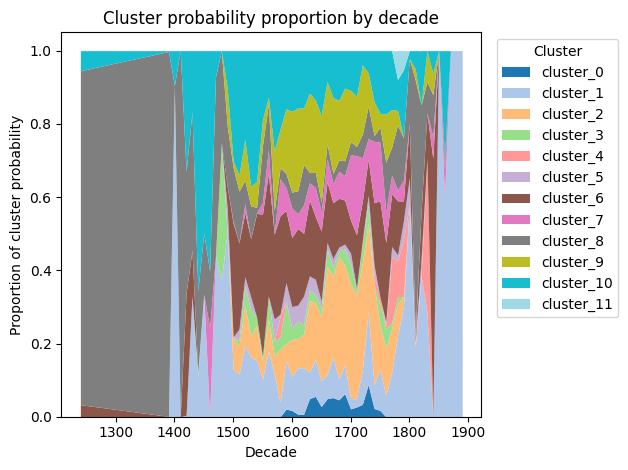

In [30]:
plt.figure(figsize=(12,6))
agg_decade_prop.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Decade')
plt.ylabel('Proportion of cluster probability')
plt.title('Cluster probability proportion by decade')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

# Do topics of earlier publications influence topics of future publications of the same researcher?

In [31]:
publications_df

,ALMA_id,autors_list,title,subtitle,publication_city,date_start,date_end,record_type,all_names,all_names_final_id,contributing_persons,contributing_organizations,genre,subjects_people,subjects_topics,subjects_places,topic_text,topic_cluster,cluster_confidence,cluster_probs
208,991000470979705067,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",na rok ... [...] /,[a: Polska | d: Kraków.],1806-01-01,1832-12-31,Tekst,"[Koch, Rudolf Bogumił (1771-post 1854), Ryszko...","(1362, 1283, 2604)","[(Ryszkowski, Franciszek Ksawery (1746-1809), ...",[(Drukarnia Antoniego Gröbla Wdowy i Sukcesoró...,"[Kalendarze, Kalendarze]",None,None,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",6,0.993430,"[5.285184e-34, 4.1358254e-12, 7.3104147e-22, 1..."
217,991000474089705067,"[Sienkiewicz, Piotr (czynny 1685-1701)]","Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...","Dum A [...] Joanne De Małachowice Małachowski,...",[a: Polska | d: Kraków.],1688-03-18,1690-03-18,Tekst,"[Schedel, Mikołaj Aleksander (1644-1708), Sien...","(2667, 2996, 2734)","[(Schedel, Mikołaj Aleksander (1644-1708), [Dr...",None,None,None,None,None,"Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...",9,0.654377,"[4.50906e-14, 2.469368e-28, 0.34561184, 4.8474..."
226,991000475869705067,"[Woysznarowicz, Kazimierz Jan ( -1680)]",Orator Politiczny Weselnym y Pogrzebowym Słvzą...,None,[a: Polska | d: Kraków.],1646-01-01,1648-12-31,Tekst,"[Woysznarowicz, Kazimierz Jan ( -1680), Cezary...","(2633, 3361, 3641)","[(Sapieha, Jan Ferdynand (1629-1659), [Adr. de...",None,"[Mowy weselne, Przemówienia polskie, Mowy pogr...",None,None,None,Orator Politiczny Weselnym y Pogrzebowym Słvzą...,9,0.996041,"[7.619563e-24, 3.8108838e-28, 1.8057952e-27, 8..."
281,991000493069705067,"[Skarszewski, Wojciech (1742-1827)]",Skutki Nowey Filozofii Spokoyności Kraiowey gr...,None,[a: Polska | d: Warszawa.],1791-01-01,1793-12-31,Tekst,"[Skarszewski, Wojciech (1742-1827), Gröll, Mic...","(990, 2767)","[(Gröll, Michał (1722-1798), [Księg.])]",None,None,None,None,None,Skutki Nowey Filozofii Spokoyności Kraiowey gr...,1,1.000000,"[0.0, 1.0, 0.0, 4.928726e-24, 0.0, 0.0, 0.0, 5..."
296,991000497659705067,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767)]",Auspicia Sandomiriensis Palatinæ Curulis Secun...,None,[a: Polska | d: Kraków.],1750-08-22,1752-08-22,Tekst,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767),...","(170, 3267)","[(Wielopolski, Jan (?-1773), [Adr. ded.])]","[(Drukarnia Akademicka (Kraków), None)]",None,None,None,None,Auspicia Sandomiriensis Palatinæ Curulis Secun...,2,0.997196,"[7.327964e-18, 4.640344e-18, 0.9971963, 2.6306..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788191,991008986109705067,"[Trigault, Nicolas (1577-1628)]","Nowiny Abo Dzieie dwuletnie Chinenskie, /",None,[a: Polska | d: Kraków.],1614-01-01,1616-12-31,None,"[Januszowski, Jan (1550-1613), Jędrzejowczyk, ...","(3681, 2407, 3378, 3126, 1207)","[(Jędrzejowczyk, Maciej (15..-1638), None), (J...",None,None,None,None,None,"Nowiny Abo Dzieie dwuletnie Chinenskie, /",1,1.000000,"[0.0, 1.0, 0.0, 1.8927163e-13, 0.0, 7.760808e-..."
788199,991008989789705067,"[Warzyński, Andrzej Paweł (16..-16..)]",Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,None,[a: Polska | d: Kraków.],1680-07-20,1682-07-20,None,"[Cezary, Franciszek (ok. 1660-1724), Warzyński...","(368, 273, 3226)","[(Bryszkiewicz, Jacek (16..-1689), [Adr. ded.]...",None,None,None,None,None,Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,2,1.000000,"[3.0470523e-21, 4.309757e-20, 1.0, 4.5152718e-..."
790406,991011913959705067,"[Jurkowski, Jan (1580-1635)]","""Tragedya o polskim Scylurusie""",None,None,1889-01-01,1889-12-31,Tekst,"[Jurkowski, Jan (1580-1635), Pauli, Żegota (18...","(2212, 1260)","[(Pauli, Żegota (1814-1895), [Kopista])]",None,None,None,None,None,"""Tragedya o polskim Scylurusie""",1,1.000000,"[0.0, 1.0, 0.0, 8.403113e-28, 0.0, 0.0, 0.0, 3..."
790498,991011937969705067,"[Władysławski, Gabriel (ca 1570-1631)]","""Inten

Similarity between present publication and older publications

In [32]:
df = publications_df.copy()

df = df.explode("all_names_final_id")
df = df.sort_values(["all_names_final_id", "date_start"], ascending=True)
df["cluster_probs"] = df["cluster_probs"].apply(np.array)

df["past_mean_cluster"] = None

def compute_history(g):
    history = []
    out = []

    for i, row in g.iterrows(): # In order from sort, so in order of date
        if len(history) == 0:
            out.append(np.zeros(best_k))
        else:
            out.append(np.mean(history, axis=0))

        history.append(row["cluster_probs"])

    g["past_mean_cluster"] = out
    return g

df = df.groupby("all_names_final_id", group_keys=False).apply(compute_history)

df["similarity_past_current_clusters"] = df.apply(
    lambda r: np.dot(r["cluster_probs"], r["past_mean_cluster"]),
    axis=1
)
print(df["similarity_past_current_clusters"])
print("Average similarity between current and past average:", df["similarity_past_current_clusters"].mean())
print("Average expected for uniform random:", 1 / best_k)
print("Average expected for random taking cluster distribution (assuming assignment into 1 cluster) into account:", (df["topic_cluster"].value_counts(normalize=True) ** 2).sum()) # /sum{p_k^2}​

46556     0.000000e+00
488259    9.998780e-01
64908     0.000000e+00
479124    9.941663e-01
6837      8.258217e-01
              ...     
591491    1.864421e-01
656857    8.563900e-03
97408     1.638591e-01
11517     5.594870e-12
213662    5.882353e-02
Name: similarity_past_current_clusters, Length: 18331, dtype: float64
Average similarity between current and past average: 0.3058877926456317
Average expected for uniform random: 0.08333333333333333
Average expected for random taking cluster distribution (assuming assignment into 1 cluster) into account: 0.12989518080143908


Topics of new publications of authors are not completely uniform random with comparison to their past topic distribution

Authors might have their own clusters (mostly earier called topics, but it can also be niches/styles/...) in which they choose to publish

# Do topics of publications of past coauthors influence topics of future publications of a researcher?

In [33]:
# author publication histories

pubs = publications_df.copy()

pubs["cluster_probs"] = pubs["cluster_probs"].apply(np.array)

pubs = pubs[[
    "ALMA_id",
    "date_start",
    "all_names_final_id",
    "cluster_probs"
]]

author_pubs = pubs.explode("all_names_final_id").rename(
    columns={"all_names_final_id": "author_id"}
)

author_pubs = author_pubs.sort_values(
    ["author_id", "date_start"]
)

# coauthor relationships

pub_authors = publications_df[
    ["ALMA_id", "date_start", "all_names_final_id"]
].copy()

pairs = []

for _, row in pub_authors.iterrows():

    authors = row["all_names_final_id"]

    if authors is None or len(authors) < 2:
        continue

    for a, b in combinations(authors, 2):
        pairs.append((a, b, row["date_start"]))
        pairs.append((b, a, row["date_start"]))

coauthor_edges = pd.DataFrame(
    pairs,
    columns=["author_id", "coauthor_id", "date"]
)

# first collaboration date

first_collab = (
    coauthor_edges
    .groupby(["author_id", "coauthor_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "first_collab_date"})
)

# author publication history lookup

author_history = {}

for author_id, g in author_pubs.groupby("author_id"):

    author_history[author_id] = {
        "dates": g["date_start"].to_numpy(),
        "clusters": np.stack(g["cluster_probs"].values)
    }

from bisect import bisect_left

def author_profile_before(author_id, cutoff_date):

    if author_id not in author_history:
        return None

    hist = author_history[author_id]

    idx = bisect_left(hist["dates"], cutoff_date)

    if idx == 0:
        return None

    return hist["clusters"][:idx].mean(axis=0)

coauthor_lookup = {}

for author_id, g in first_collab.groupby("author_id"):

    coauthor_lookup[author_id] = list(
        zip(
            g["coauthor_id"],
            g["first_collab_date"]
        )
    )

def coauthor_profile(author_id, date):

    profiles = []

    for coauthor_id, first_date in coauthor_lookup.get(author_id, []):

        if first_date >= date:
            continue

        profile = author_profile_before(
            coauthor_id,
            date
        )

        if profile is not None:
            profiles.append(profile)

    if not profiles:
        return np.zeros(best_k)

    return np.mean(profiles, axis=0)

author_pubs["coauthor_profile"] = author_pubs.apply(
    lambda r: coauthor_profile(
        r["author_id"],
        r["date_start"]
    ),
    axis=1
)

author_pubs["coauthor_similarity"] = author_pubs.apply(
    lambda r: np.dot(
        r["cluster_probs"],
        r["coauthor_profile"]
    ),
    axis=1
)

print(
    "Mean coauthor-history similarity:",
    author_pubs["coauthor_similarity"].mean()
)

Mean coauthor-history similarity: 0.12517553260615166


Topics of historical coauthor publications do not strongly influence topics of new publications of researchers

# Agent-Based Model

## Data Structures: Agent - Researcher, Publication - at Specific Time Step
Researcher has:
- ID (from `all_names_final_id` in `publications_df`)
- date of first publication (earliest `date_start` when that id appeared in `all_names_final_id`)
- vector of past publication IDs (row ids from `publications_df` which appeared before time seen as current)

Publication has:
- ID (from row id in `publications_df`)
- list of researcher IDs (from `all_names_final_id`)
- topic vector, always of same length, with values between 0 and 1 (from `cluster_probs` which are `list`s, but here they are converted to `np.array`, they are all of same length)

Such state (container with series of Researcher, and of Publication) would appear at each time step in simulation

## Populate These More Convenient Dataframes

Simulation results would be stored that way, and historical data would be converted to it for comparisons

In [ ]:
from collections import defaultdict

In [158]:
def to_timed_states(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
) -> dict[pd.Timestamp, tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Convert a publication dataframe into a sequence of temporal snapshots

    Each snapshot represents the state of the publication system at a specific time point

    Researcher state:
        - researcher_id
        - first_publication_date (earliest publication date seen so far)
        - publication_ids (all publications published before or at the current snapshot date)

    Publication state:
        - publication_id (original dataframe index)
        - date_start
        - researcher_ids
        - topic_vector

    Researchers are considered active only if they have at least one publication within the current time window
    Researchers whose last publication is older than the current window are not present in the researcher table for that snapshot

    Parameters

    publications_df
        DataFrame which has to contain at least:
            - date_start
            - all_names_final_id
            - cluster_probs

    time_step
        Length of one temporal step

    Returns

    dict
        Mapping

            snapshot_date ->
                (
                    researchers_df,
                    publications_df
                )

        where each dataframe describes the state at that step
    """

    df = publications_df.copy()

    df["date_start"] = pd.to_datetime(df["date_start"])

    df = (
        df.reset_index(names="publication_id")
          .sort_values("date_start")
          .reset_index(drop=True)
    )

    start_date = df["date_start"].min().floor("D")
    end_date = df["date_start"].max().ceil("D")

    states = {}

    current_date = start_date

    while current_date <= end_date:

        # Publications visible up to current time
        visible_pubs = df.loc[df["date_start"] <= current_date]

        # Publications in current activity window
        window_start = current_date - pd.Timedelta(time_step)

        recent_pubs = df.loc[
            (df["date_start"] > window_start)
            & (df["date_start"] <= current_date)
        ]

        # Build publication table

        publications_state = pd.DataFrame(
            {
                "publication_id": visible_pubs["publication_id"],
                "date_start": visible_pubs["date_start"],
                "researcher_ids": visible_pubs["all_names_final_id"],
                "topic_vector": visible_pubs["cluster_probs"],
            }
        )

        # Build researcher table

        publication_history = defaultdict(list)
        first_publication_date = {}

        for _, row in visible_pubs.iterrows():

            pub_id = row["publication_id"]
            pub_date = row["date_start"]

            researcher_ids = row["all_names_final_id"]

            if researcher_ids is None:
                continue

            for researcher_id in researcher_ids:

                publication_history[researcher_id].append(pub_id)

                if (
                    researcher_id not in first_publication_date
                    or pub_date < first_publication_date[researcher_id]
                ):
                    first_publication_date[researcher_id] = pub_date

        # Active researchers havy any publication in current window
        active_ids = set()

        for ids in recent_pubs["all_names_final_id"]:

            if ids is None:
                continue

            active_ids.update(ids)

        researchers_state = pd.DataFrame(
            [
                {
                    "researcher_id": researcher_id,
                    "first_publication_date": first_publication_date[researcher_id],
                    "publication_ids": publication_history[researcher_id],
                }
                for researcher_id in active_ids
            ],
            columns=[
                "researcher_id",
                "first_publication_date",
                "publication_ids",
            ],
        )

        states[current_date] = (
            researchers_state,
            publications_state,
        )

        current_date += pd.Timedelta(time_step)

    return states

Helper function which would be used for graph analysis at the end

In [ ]:
def to_coauthorship_edge_list(publications_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a coauthorship edge list from publications_df

    Each row represents a collaboration between two researchers on a single publication

    Parameters

    publications_df
        DataFrame containing at least:
            - all_names_final_id
            - date_start

        The dataframe index is assumed to be the publication ID

    Returns

    pd.DataFrame
        Columns:
            researcher_a : int
            researcher_b : int
            publication_id : int
            date_start : datetime

        One row per coauthor pair per publication
    """

    rows = []

    for publication_id, row in publications_df.iterrows():

        researcher_ids = row["all_names_final_id"]

        if not researcher_ids:
            continue

        researcher_ids = sorted(set(researcher_ids))

        if len(researcher_ids) < 2:
            continue

        for researcher_a, researcher_b in combinations(
            researcher_ids,
            2,
        ):
            rows.append(
                {
                    "researcher_a": researcher_a,
                    "researcher_b": researcher_b,
                    "publication_id": publication_id,
                    "date_start": row["date_start"],
                }
            )

    return pd.DataFrame(rows)

## Estimation of parameters basing on real data

### How many new researchers appear

Exploration of how many new researchers appeared at certain buckets with certain time steps

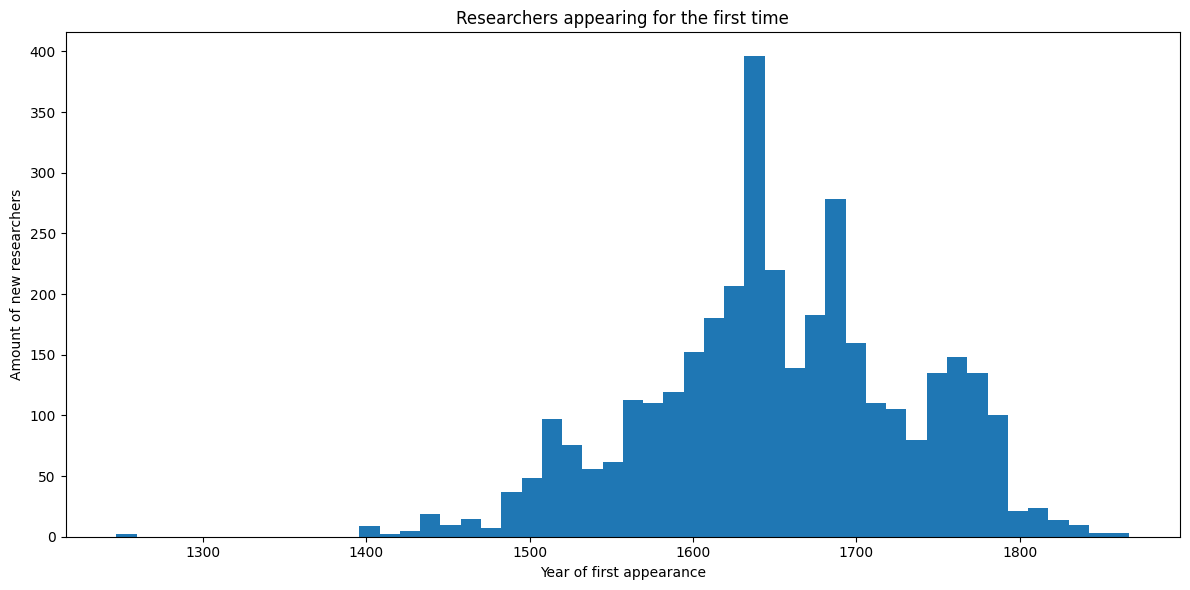

In [89]:
# Make sure dates are datetime
df = publications_df.copy()
df["date_start"] = pd.to_datetime(df["date_start"])

# Earliest appearance of each researcher
first_publication_date = {}

for _, row in df.iterrows():
    researcher_ids = row["all_names_final_id"]
    pub_date = row["date_start"]

    if researcher_ids is None:
        continue

    for researcher_id in researcher_ids:
        if (
            researcher_id not in first_publication_date
            or pub_date < first_publication_date[researcher_id]
        ):
            first_publication_date[researcher_id] = pub_date

# Convert to Series
first_dates = pd.Series(first_publication_date)

# Histogram by year
years = first_dates.dt.year

plt.figure(figsize=(12, 6))
plt.hist(years, bins=50)
plt.xlabel("Year of first appearance")
plt.ylabel("Amount of new researchers")
plt.title("Researchers appearing for the first time")
plt.tight_layout()
plt.show()

Implementation (to not have to rebuild, a closure function is returned)

In [90]:
from sklearn.linear_model import LinearRegression

In [106]:
def build_new_researchers_model(
    publications_df: pd.DataFrame,
    step_duration: pd.Timedelta,
):
    df = publications_df.copy()
    df["date_start"] = pd.to_datetime(df["date_start"])

    # Earliest appearance of each researcher
    first_publication_date = {}

    for _, row in df.iterrows():
        researcher_ids = row["all_names_final_id"]
        pub_date = row["date_start"]

        if researcher_ids is None:
            continue

        for researcher_id in researcher_ids:
            if (
                researcher_id not in first_publication_date
                or pub_date < first_publication_date[researcher_id]
            ):
                first_publication_date[researcher_id] = pub_date

    first_dates = pd.Series(first_publication_date)

    # Create bins of arbitrary width
    start_date = first_dates.min().floor("D")
    bin_index = ((first_dates - start_date) // step_duration).astype(int)

    counts = (
        bin_index.value_counts()
        .sort_index()
    )

    # Bin centers in days since start_date
    x = np.array([
        (start_date + i * step_duration - start_date).total_seconds()
        / 86400
        for i in counts.index
    ])

    y = counts.values.astype(float)

    # Spline interpolation with Extrapolation
    interpolator = interp1d(
        x,
        y,
        kind="cubic",
        fill_value="extrapolate",
        bounds_error=False,
    )

    def how_many_new_researchers(date_now: pd.Timestamp) -> int:
        t = (
            (pd.Timestamp(date_now) - start_date)
            .total_seconds()
            / 86400
        )

        estimate = float(interpolator(t))

        return max(0, round(estimate))

    return how_many_new_researchers

Check whether it approximates the new counts of researchers properly

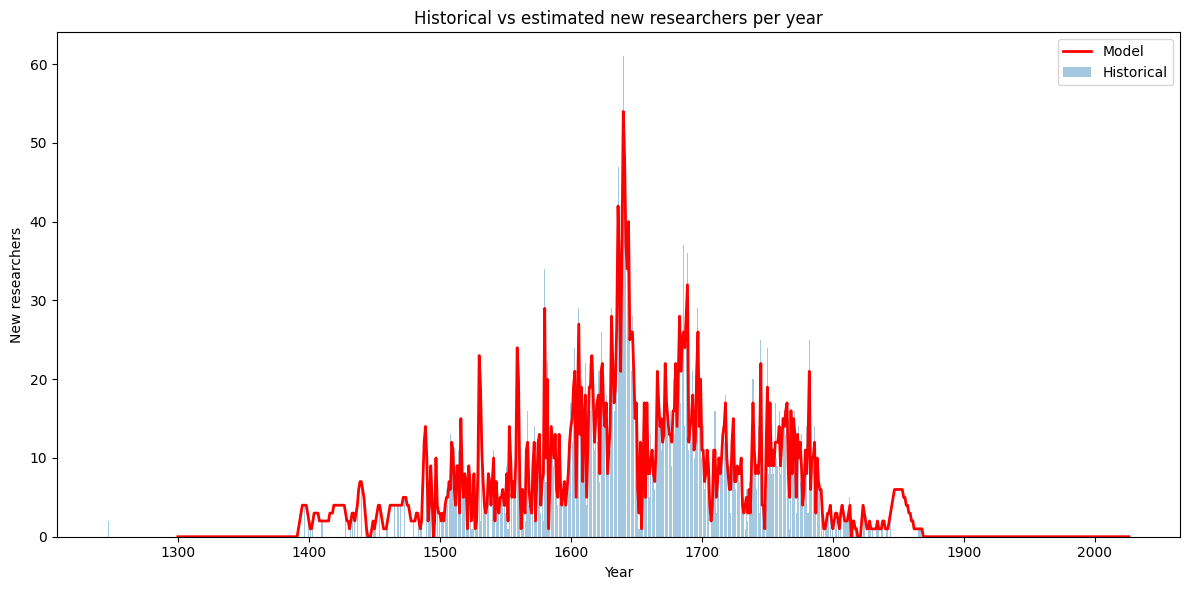

In [107]:
hmnr = build_new_researchers_model(publications_df, pd.Timedelta(days=365))

years = np.arange(1300, 2027)

estimated = [
    hmnr(pd.Timestamp(f"{year}-01-01"))
    for year in years
]

# Historical counts
first_dates = pd.Series(first_publication_date)
historical_counts = (
    first_dates.dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.bar(
    historical_counts.index,
    historical_counts.values,
    alpha=0.4,
    label="Historical"
)

plt.plot(
    years,
    estimated,
    color="red",
    linewidth=2,
    label="Model"
)

plt.xlabel("Year")
plt.ylabel("New researchers")
plt.title("Historical vs estimated new researchers per year")
plt.legend()

plt.tight_layout()
plt.show()

### Probability of Researcher Quitting at Certain Age

Exploration of for how long researchers have published

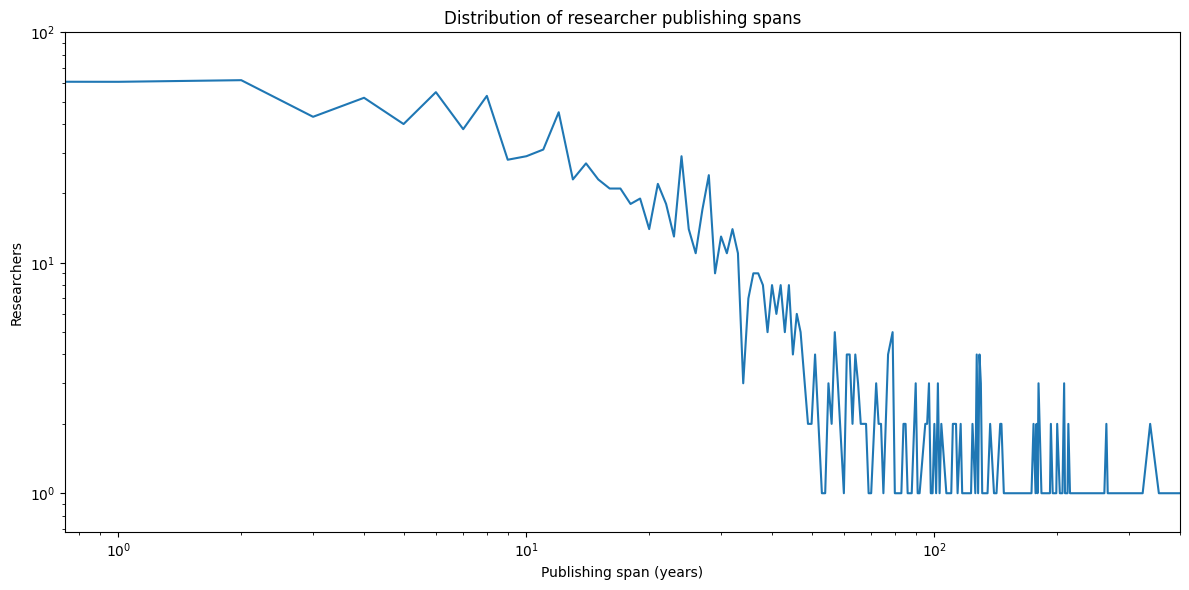

In [ ]:
df = publications_df.copy()
df["date_start"] = pd.to_datetime(df["date_start"])

first_pub = {}
last_pub = {}

for _, row in df.iterrows():
    researcher_ids = row["all_names_final_id"]
    pub_date = row["date_start"]

    if researcher_ids is None:
        continue

    for researcher_id in researcher_ids:

        # first publication
        if (
            researcher_id not in first_pub
            or pub_date < first_pub[researcher_id]
        ):
            first_pub[researcher_id] = pub_date

        # last publication
        if (
            researcher_id not in last_pub
            or pub_date > last_pub[researcher_id]
        ):
            last_pub[researcher_id] = pub_date

# DataFrame with careers
career_df = pd.DataFrame({
    "first_pub": pd.Series(first_pub),
    "last_pub": pd.Series(last_pub),
})

career_df["duration_days"] = (
    career_df["last_pub"] - career_df["first_pub"]
).dt.days

career_df["duration_years"] = (
    career_df["duration_days"] / 365.25
)

duration_years_int = career_df["duration_years"].astype(int)

counts = duration_years_int.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(counts.index, counts.values)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0, 400)
ax.set_ylim(0, 100)
ax.set_xlabel("Publishing span (years)")
ax.set_ylabel("Researchers")
ax.set_title("Distribution of researcher publishing spans")
plt.tight_layout()
plt.show()

Exploration of quit probability

Let (D) be a researcher's total publishing duration (in years)

For researchers who have already published for (t) years, the probability of quitting at that point is:

$$ P(D=t \mid D \ge t) $$

(discrete-time hazard rate)

For each duration (t):

- at risk: researchers with duration ≥ (t)
- quitters: researchers with duration = (t)
- hazard: quitters / at_risk

In [71]:
durations = career_df["duration_years"].astype(int)

max_t = durations.max()

hazard = []
at_risk = []
quitters = []

for t in range(max_t + 1):
    n_at_risk = (durations >= t).sum()
    n_quitters = (durations == t).sum()

    at_risk.append(n_at_risk)
    quitters.append(n_quitters)

    if n_at_risk > 0:
        hazard.append(n_quitters / n_at_risk)
    else:
        hazard.append(np.nan)

hazard_df = pd.DataFrame({
    "duration": range(max_t + 1),
    "at_risk": at_risk,
    "quitters": quitters,
    "hazard": hazard,
})

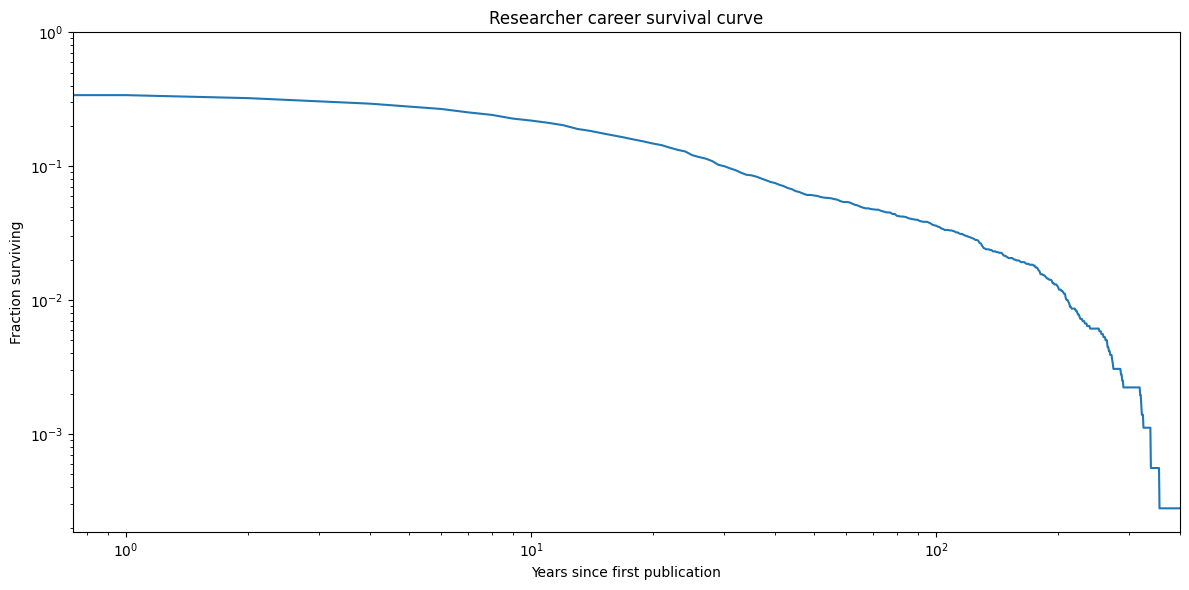

In [124]:
survival = [
    (durations >= t).mean()
    for t in range(max_t + 1)
]

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(range(max_t + 1), survival)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0, 400)
ax.set_ylim(0, 1)
ax.set_xlabel("Years since first publication")
ax.set_ylabel("Fraction surviving")
ax.set_title("Researcher career survival curve")

plt.tight_layout()
plt.show()

Implementation

In [ ]:
def build_researcher_quit_model(
    publications_df: pd.DataFrame,
    step_duration: pd.Timedelta,
):
    df = publications_df.copy()
    df["date_start"] = pd.to_datetime(df["date_start"])

    first_pub = {}
    last_pub = {}

    # build career spans
    for _, row in df.iterrows():
        researcher_ids = row["all_names_final_id"]
        pub_date = row["date_start"]

        if researcher_ids is None:
            continue

        for rid in researcher_ids:
            if rid not in first_pub or pub_date < first_pub[rid]:
                first_pub[rid] = pub_date
            if rid not in last_pub or pub_date > last_pub[rid]:
                last_pub[rid] = pub_date

    first = pd.Series(first_pub)
    last = pd.Series(last_pub)

    durations = (last - first)

    # align to step grid
    start_date = first.min().floor("D")

    def to_steps(td):
        return (td / step_duration).astype(float)

    duration_steps = to_steps(durations)

    # survival function estimator
    max_step = int(np.ceil(duration_steps.max()))

    survival = np.array([
        (duration_steps >= t).mean()
        for t in range(max_step + 1)
    ])

    survival = np.clip(survival, 1e-12, 1.0)  # numerical stability

    # hazard per step
    hazard = np.zeros_like(survival)
    hazard[:-1] = (survival[:-1] - survival[1:]) / survival[:-1]
    hazard[-1] = np.nan

    def quit_researcher_probability(
        step_duration: pd.Timedelta,
        first_publication_date: pd.Timestamp,
        date_now: pd.Timestamp
    ) -> float:

        # how many steps survived so far
        t = (date_now - first_publication_date) / step_duration
        t = int(np.floor(t))

        if t < 0:
            return 0.0
        if t >= len(hazard):
            return 1.0  # outside observed range so assume absorbed

        return float(hazard[t])

    return quit_researcher_probability

Check

[3.45961003e-01 3.24791086e-01 3.06963788e-01 2.93314763e-01
 2.81894150e-01 2.69916435e-01 2.53481894e-01 2.42061281e-01
 2.31476323e-01 2.20334262e-01 2.11699164e-01 2.02506964e-01
 1.92757660e-01 1.84679666e-01 1.77994429e-01 1.70194986e-01
 1.66295265e-01 1.59052925e-01 1.53481894e-01 1.48467967e-01
 1.44289694e-01 1.39554318e-01 1.33704735e-01 1.29526462e-01
 1.22841226e-01 1.17270195e-01 1.14484680e-01 1.10027855e-01
 1.04735376e-01 1.01114206e-01 9.69359331e-02 9.38718663e-02
 9.05292479e-02 8.69080780e-02 8.57938719e-02 8.38440111e-02
 8.21727019e-02 7.91086351e-02 7.68802228e-02 7.49303621e-02
 7.35376045e-02 7.15877437e-02 6.96378830e-02 6.74094708e-02
 6.54596100e-02 6.43454039e-02 6.23955432e-02 6.10027855e-02
 6.10027855e-02 6.07242340e-02 5.98885794e-02 5.87743733e-02
 5.82172702e-02 5.82172702e-02 5.76601671e-02 5.71030641e-02
 5.62674095e-02 5.51532033e-02 5.40389972e-02 5.40389972e-02
 5.37604457e-02 5.29247911e-02 5.18105850e-02 5.09749304e-02
 5.06963788e-02 4.902506

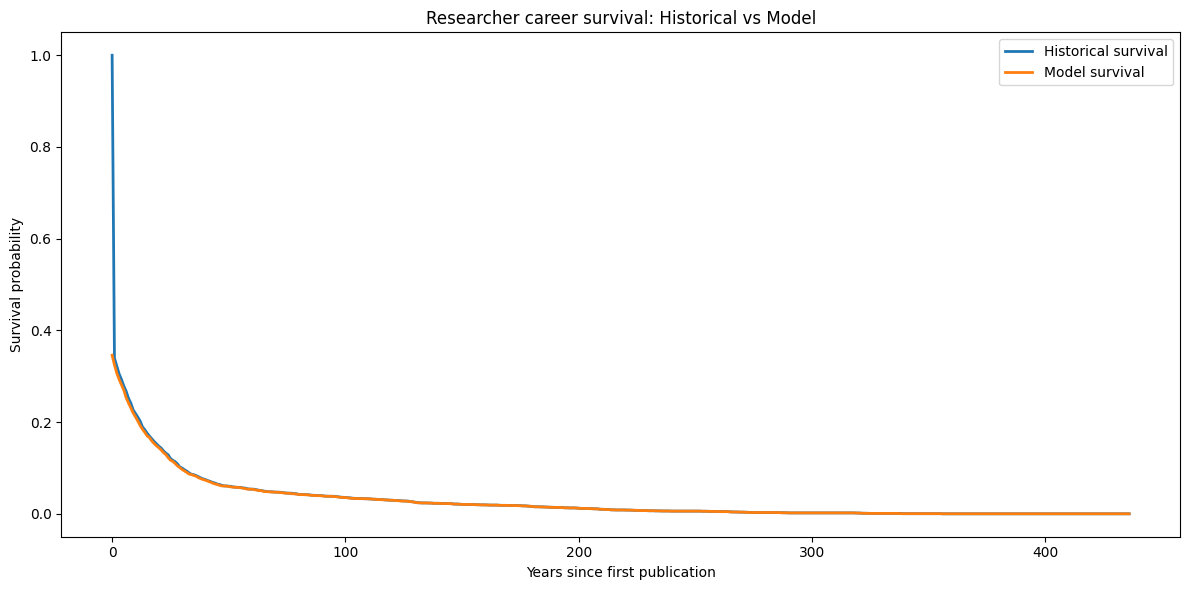

In [131]:
rqp = build_researcher_quit_model(
    publications_df,
    pd.Timedelta(days=365)
)

empirical_survival = np.array(survival)
t_empirical = np.arange(len(empirical_survival))

model_survival = np.ones(len(empirical_survival))

for t in range(0, len(empirical_survival)):
    h = rqp(
        pd.Timedelta(days=365),
        pd.Timestamp("1900-01-01"), # only relative duration matters as of present implementation
        pd.Timestamp(f"{1900 + t}-01-01")
    )
    model_survival[t] = model_survival[t - 1] * (1 - h)

print(model_survival)

plt.figure(figsize=(12, 6))

plt.plot(
    t_empirical,
    empirical_survival,
    label="Historical survival",
    linewidth=2
)

plt.plot(
    t_empirical,
    model_survival,
    label="Model survival",
    linewidth=2
)

plt.xlabel("Years since first publication")
plt.ylabel("Survival probability")
plt.title("Researcher career survival: Historical vs Model")
plt.legend()

plt.tight_layout()
plt.show()

## Decision Functions on Group selection

### Mean of publication counts per step as a proportion of researcher amount, Mean of author counts per publication as a proportion of researcher amount, Always same relative publication count, Always same relative author amount

In [ ]:
def build_collaborate_model_with_publication_amount_author_amount_mean_proportional(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    rng = np.random.default_rng(random_state)

    states = to_timed_states(publications_df, time_step)

    publication_rates = []
    author_proportions = []

    previous_pub_count = 0

    for _, (researchers, pubs) in sorted(states.items()):

        n_active = len(researchers)

        current_pub_count = len(pubs)

        new_publications = (
            current_pub_count - previous_pub_count
        )

        previous_pub_count = current_pub_count

        if n_active == 0:
            continue

        # publications per active researcher
        publication_rates.append(
            new_publications / n_active
        )

        # author count proportion among newly appearing publications
        if new_publications > 0:

            new_pubs = pubs.tail(new_publications)

            for researcher_ids in new_pubs["researcher_ids"]:

                if researcher_ids is None:
                    continue

                n_authors = len(researcher_ids)

                author_proportions.append(
                    n_authors / n_active
                )

    mean_publications_per_active_researcher_at_step = (
        float(np.mean(publication_rates))
        if publication_rates
        else 0.0
    )

    mean_author_proportion = (
        float(np.mean(author_proportions))
        if author_proportions
        else 0.0
    )

    def decide_collaborate(
        active_researchers: pd.DataFrame, # These researchers and publications could have not appeared in publications_df
        publications: pd.DataFrame,
    ) -> list[list[int]]:

        active_ids = active_researchers[
            "researcher_id"
        ].tolist()

        n_active = len(active_ids)

        if n_active == 0:
            return []

        # expected publications this step
        expected_publications_amount = (
            mean_publications_per_active_researcher_at_step
            * n_active
        )

        collaborations = []

        for _ in range(expected_publications_amount):

            expected_authors_amount = (
                mean_author_proportion
                * n_active
            )

            authors = rng.choice(
                active_ids,
                size=expected_authors_amount,
                replace=False,
            )

            collaborations.append(
                list(map(int, authors))
            )

        return collaborations

    return decide_collaborate

### Distribution of publication counts per step as a proportion of researcher amount, Distribution of author counts per publication as a proportion of researcher amount

Exploration

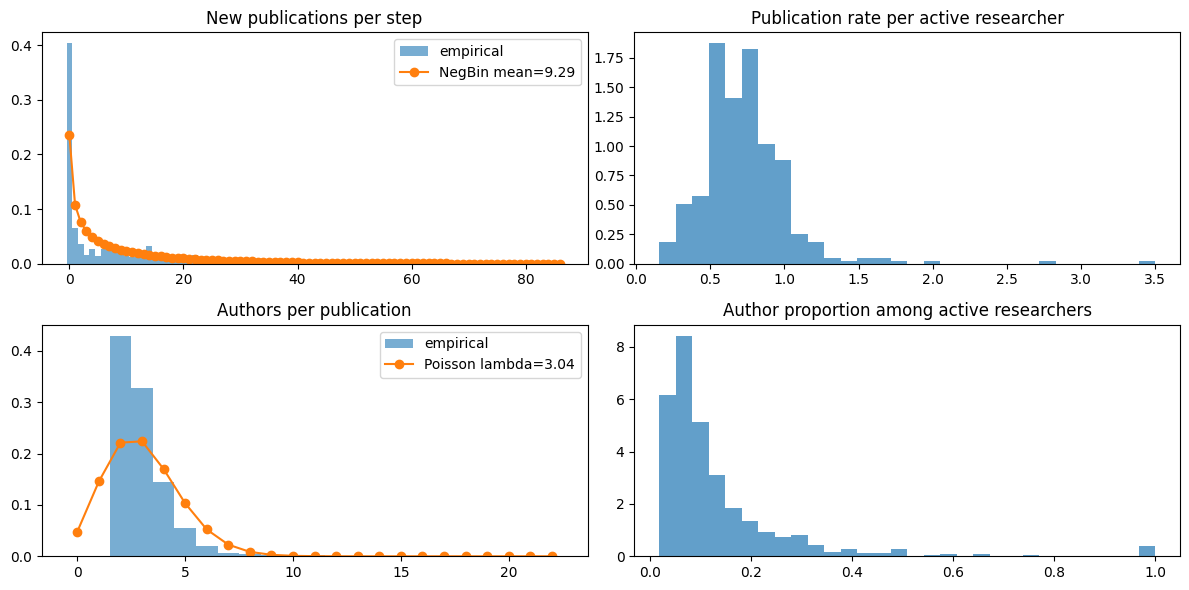

New publications:
mean=9.289, var=188.596, var/mean=20.303

Authors per publication:
mean=3.036, var=2.131, var/mean=0.702


In [134]:
from scipy.stats import poisson, nbinom

states = to_timed_states(
    publications_df,
    time_step=pd.Timedelta(days=365),
)

publication_counts = []
publication_rates = []

author_counts = []
author_proportions = []

previous_pub_count = 0

for _, (researchers, pubs) in sorted(states.items()):

    n_active = len(researchers)

    current_pub_count = len(pubs)

    new_publications = current_pub_count - previous_pub_count
    previous_pub_count = current_pub_count

    publication_counts.append(new_publications)

    if n_active > 0:
        publication_rates.append(
            new_publications / n_active
        )

    if new_publications > 0 and n_active > 0:

        new_pubs = pubs.tail(new_publications)

        for ids in new_pubs["researcher_ids"]:

            if ids is None:
                continue

            n_authors = len(ids)

            author_counts.append(n_authors)
            author_proportions.append(
                n_authors / n_active
            )

publication_counts = np.asarray(publication_counts)
publication_rates = np.asarray(publication_rates)

author_counts = np.asarray(author_counts)
author_proportions = np.asarray(author_proportions)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 6),
)

# New publication counts

ax = axes[0, 0]

mu = publication_counts.mean()
var = publication_counts.var()

# moment matching
k = mu**2 / (var - mu)

p = k / (k + mu)

bins = np.arange(
    publication_counts.max() + 2
) - 0.5

ax.hist(
    publication_counts,
    bins=bins,
    density=True,
    alpha=0.6,
    label="empirical",
)

x = np.arange(
    publication_counts.max() + 1
)

ax.plot(
    x,
    nbinom.pmf(x, k, p),
    "o-",
    label=f"NegBin mean={mu:.2f}",
)

ax.set_title(
    "New publications per step"
)

ax.legend()

# Publication rate

ax = axes[0, 1]

ax.hist(
    publication_rates,
    bins=30,
    density=True,
    alpha=0.7,
)

ax.set_title(
    "Publication rate per active researcher"
)

# Author counts

ax = axes[1, 0]

lam = author_counts.mean()

bins = np.arange(
    author_counts.max() + 2
) - 0.5

ax.hist(
    author_counts,
    bins=bins,
    density=True,
    alpha=0.6,
    label="empirical",
)

x = np.arange(
    author_counts.max() + 1
)

ax.plot(
    x,
    poisson.pmf(x, lam),
    "o-",
    label=f"Poisson lambda={lam:.2f}",
)

ax.set_title(
    "Authors per publication"
)

ax.legend()

# Author proportion

ax = axes[1, 1]

ax.hist(
    author_proportions,
    bins=30,
    density=True,
    alpha=0.7,
)

ax.set_title(
    "Author proportion among active researchers"
)

plt.tight_layout()
plt.show()

# Diagnostics

print(
    "New publications:"
)
print(
    f"mean={publication_counts.mean():.3f}, "
    f"var={publication_counts.var():.3f}, "
    f"var/mean={publication_counts.var()/publication_counts.mean():.3f}"
)

print()

print(
    "Authors per publication:"
)
print(
    f"mean={author_counts.mean():.3f}, "
    f"var={author_counts.var():.3f}, "
    f"var/mean={author_counts.var()/author_counts.mean():.3f}"
)

# How well Possion distribution fits
# Poisson has variance equal to mean
# var / mean
# similar to 1 -> Poisson is plausible
# larger than 1 -> overdispersed, negative binomial would fit better
# smaller than 1 -> Poisson is too wide, Binomial/Beta-Binomial style model may fit better.

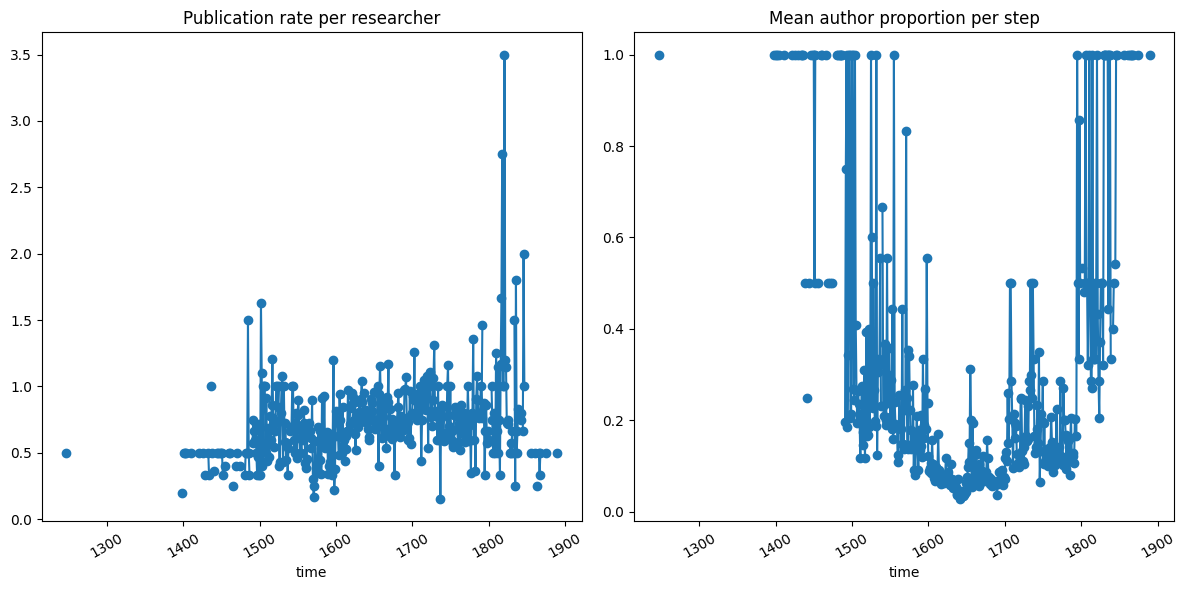

In [136]:
steps, pub_rate_ts, auth_prop_ts = [], [], []

prev = 0
for t, (researchers, pubs) in sorted(states.items()):
    n_active = len(researchers)
    new = len(pubs) - prev
    prev = len(pubs)
    steps.append(t)
    pub_rate_ts.append(new / n_active if n_active>0 else np.nan)
    # mean author proportion among new pubs this step
    if new>0 and n_active>0:
        new_pubs = pubs.tail(new)
        props = [len(ids)/n_active for ids in new_pubs["researcher_ids"] if ids is not None]
        auth_prop_ts.append(np.nan if len(props)==0 else np.mean(props))
    else:
        auth_prop_ts.append(np.nan)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(steps, pub_rate_ts, "-o")
plt.title("Publication rate per researcher")
plt.xlabel("time"); plt.xticks(rotation=30)

plt.subplot(1,2,2)
plt.plot(steps, auth_prop_ts, "-o")
plt.title("Mean author proportion per step")
plt.xlabel("time"); plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


Implementation

In [ ]:
def build_collaborate_model_with_publication_amount_author_amount_distribution_proportional(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    rng = np.random.default_rng(random_state)

    states = to_timed_states(publications_df, time_step)

    publication_rates = []
    author_proportions = []

    previous_pub_count = 0

    for _, (researchers, pubs) in sorted(states.items()):

        n_active = len(researchers)

        current_pub_count = len(pubs)

        new_publications = (
            current_pub_count - previous_pub_count
        )

        previous_pub_count = current_pub_count

        if n_active == 0:
            continue

        # publications per active researcher
        publication_rates.append(
            new_publications / n_active
        )

        # author count proportion among newly appearing publications
        if new_publications > 0:

            new_pubs = pubs.tail(new_publications)

            for researcher_ids in new_pubs["researcher_ids"]:

                if researcher_ids is None:
                    continue

                n_authors = len(researcher_ids)

                author_proportions.append(
                    n_authors / n_active
                )

    mean_publications_per_active_researcher_at_step = (
        float(np.mean(publication_rates))
        if publication_rates
        else 0.0
    )

    variance_publications_per_active_researcher_at_step = (
        float(np.var(publication_counts))
        if publication_rates
        else 0.0
    )

    # moment matching
    k = mean_publications_per_active_researcher_at_step**2 / (variance_publications_per_active_researcher_at_step - mean_publications_per_active_researcher_at_step)
    p = k / (k + mean_publications_per_active_researcher_at_step)

    mean_author_proportion = (
        float(np.mean(author_proportions))
        if author_proportions
        else 0.0
    )

    def decide_collaborate(
        active_researchers: pd.DataFrame, # These researchers and publications could have not appeared in publications_df
        publications: pd.DataFrame,
    ) -> list[list[int]]:

        active_ids = active_researchers[
            "researcher_id"
        ].tolist()

        n_active = len(active_ids)

        if n_active == 0:
            return []

        # expected publications this step
        expected_publications = (
            mean_publications_per_active_researcher_at_step
            * n_active
        )

        n_new_publications = int(
            rng.poisson(expected_publications)
        )

        collaborations = []

        for _ in range(n_new_publications):

            expected_authors = (
                mean_author_proportion
                * n_active
            )

            n_authors = int(
                rng.negative_binomial(expected_authors, p)
            )

            # clamp
            n_authors = max(1, n_authors)
            n_authors = min(
                n_authors,
                n_active,
            )

            authors = rng.choice(
                active_ids,
                size=n_authors,
                replace=False,
            )

            collaborations.append(
                list(map(int, authors))
            )

        return collaborations

    return decide_collaborate

### Distribution of publication counts per step as a proportion of researcher amount, Distribution of author counts per publication as a proportion of researcher amount, Researcher publication amount as a proportion of researcher amount

Exploration

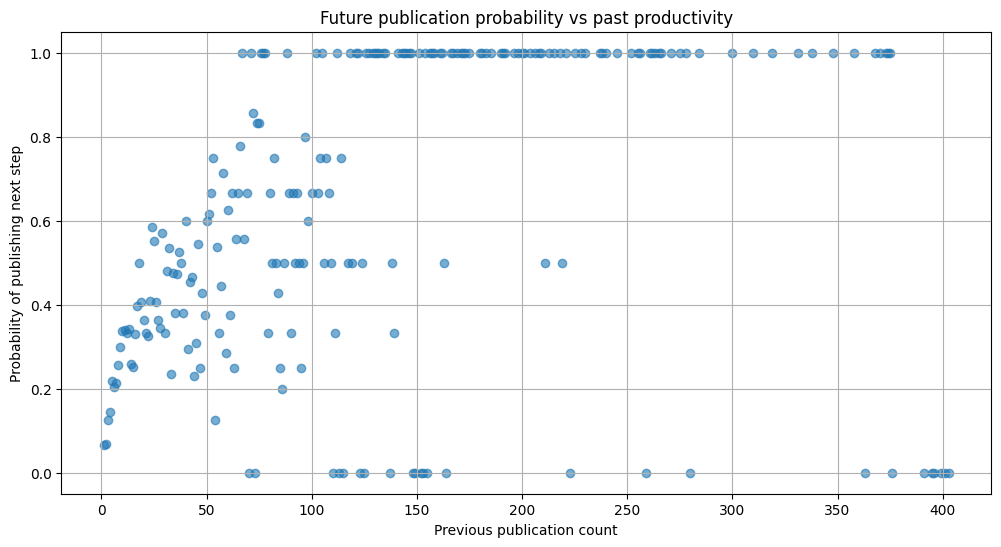

In [153]:
states = to_timed_states(
    publications_df,
    pd.Timedelta(days=365),
)

snapshots = sorted(states.items())

rows = []

for i in range(len(snapshots) - 1):

    _, (researchers_now, pubs_now) = snapshots[i]
    _, (_, pubs_next) = snapshots[i + 1]

    current_pub_ids = set(
        pubs_now["publication_id"]
    )

    next_pub_ids = set(
        pubs_next["publication_id"]
    )

    new_pub_ids = next_pub_ids - current_pub_ids

    new_pubs = pubs_next[
        pubs_next["publication_id"].isin(
            new_pub_ids
        )
    ]

    selected_next = set()

    for ids in new_pubs["researcher_ids"]:

        if ids is None:
            continue

        selected_next.update(ids)

    for _, researcher in researchers_now.iterrows():

        researcher_id = researcher[
            "researcher_id"
        ]

        n_previous_publications = len(
            researcher["publication_ids"]
        )

        rows.append(
            {
                "publication_count":
                    n_previous_publications,
                "selected_next":
                    int(
                        researcher_id
                        in selected_next
                    ),
            }
        )

df = pd.DataFrame(rows)

curve = (
    df.groupby("publication_count")
        ["selected_next"]
        .mean()
        .reset_index()
)

plt.figure(figsize=(12, 6))

plt.scatter(
    curve["publication_count"],
    curve["selected_next"],
    alpha=0.6,
)

plt.xlabel(
    "Previous publication count"
)

plt.ylabel(
    "Probability of publishing next step"
)

plt.title(
    "Future publication probability vs past productivity"
)

plt.grid(True)

plt.show()

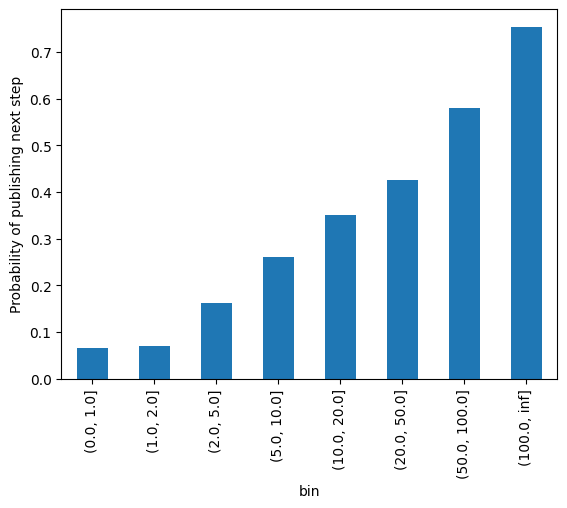

In [154]:
curve["bin"] = pd.cut(
    curve["publication_count"],
    bins=[
        0,
        1,
        2,
        5,
        10,
        20,
        50,
        100,
        np.inf,
    ],
)

summary = (
    curve.groupby("bin")
    ["selected_next"]
    .mean()
)

summary.plot.bar()
plt.ylabel(
    "Probability of publishing next step"
)
plt.show() # https://en.wikipedia.org/wiki/Preferential_attachment is present, having published many publications increases probability of publishing more

Estimate exponent for weights

In [170]:
from scipy.optimize import minimize_scalar
import numpy as np

records = []

for i in range(len(snapshots) - 1):

    _, (researchers_now, pubs_now) = snapshots[i]
    _, (_, pubs_next) = snapshots[i + 1]

    if (researchers_now is None or pubs_now is None or pubs_next is None
        or researchers_now.empty or pubs_now.empty or pubs_next.empty):
        # It collects selected using next already, so empty data can be skipped
        # records.append(
        #     {
        #         "counts": dict(),
        #         "selected": [],
        #     }
        # )
        continue

    current_pub_ids = set(pubs_now["publication_id"])
    next_pub_ids = set(pubs_next["publication_id"])

    new_pub_ids = next_pub_ids - current_pub_ids

    new_pubs = pubs_next[
        pubs_next["publication_id"].isin(new_pub_ids)
    ]

    selected = []

    for ids in new_pubs["researcher_ids"]:
        if ids is not None:
            selected.extend(ids)

    counts = dict(
        zip(
            researchers_now["researcher_id"],
            researchers_now["publication_ids"].apply(len),
        )
    )

    records.append(
        {
            "counts": counts,
            "selected": selected,
        }
    )

def negative_log_likelihood(alpha):

    ll = 0.0

    for record in records:

        counts = record["counts"]

        researcher_ids = np.array(
            list(counts.keys())
        )

        c = np.array(
            [counts[r] + 1 for r in researcher_ids],
            dtype=float,
        )

        weights = c ** alpha
        probs = weights / weights.sum()

        lookup = dict(
            zip(researcher_ids, probs)
        )

        for researcher_id in record["selected"]:

            if researcher_id in lookup:
                ll += np.log(
                    lookup[researcher_id]
                )

    return -ll

result = minimize_scalar(
    negative_log_likelihood,
    bounds=(-2, 3),
    method="bounded",
)

print(result)

 message: Solution found.
 success: True
  status: 0
     fun: 17500.275616521812
       x: 0.8536813030033487
     nit: 10
    nfev: 10


Implementation

In [ ]:
def build_collaborate_model_with_publication_amount_author_amount_distribution_proportional(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
    alpha: float = 0.8536813030033487, # Parameter of preferential author choice, default value is from computation on historical data
):
    rng = np.random.default_rng(random_state)

    states = to_timed_states(publications_df, time_step)

    publication_rates = []
    author_proportions = []

    previous_pub_count = 0

    for _, (researchers, pubs) in sorted(states.items()):

        n_active = len(researchers)

        current_pub_count = len(pubs)

        new_publications = (
            current_pub_count - previous_pub_count
        )

        previous_pub_count = current_pub_count

        if n_active == 0:
            continue

        # publications per active researcher
        publication_rates.append(
            new_publications / n_active
        )

        # author count proportion among newly appearing publications
        if new_publications > 0:

            new_pubs = pubs.tail(new_publications)

            for researcher_ids in new_pubs["researcher_ids"]:

                if researcher_ids is None:
                    continue

                n_authors = len(researcher_ids)

                author_proportions.append(
                    n_authors / n_active
                )

    mean_publications_per_active_researcher_at_step = (
        float(np.mean(publication_rates))
        if publication_rates
        else 0.0
    )

    variance_publications_per_active_researcher_at_step = (
        float(np.var(publication_counts))
        if publication_rates
        else 0.0
    )

    # moment matching
    k = mean_publications_per_active_researcher_at_step**2 / (variance_publications_per_active_researcher_at_step - mean_publications_per_active_researcher_at_step)
    p = k / (k + mean_publications_per_active_researcher_at_step)

    mean_author_proportion = (
        float(np.mean(author_proportions))
        if author_proportions
        else 0.0
    )

    def decide_collaborate(
        active_researchers: pd.DataFrame, # These researchers and publications should be assumed to have not appeared in publications_df at all
        publications: pd.DataFrame,
    ) -> list[list[int]]:

        active_ids = active_researchers[
            "researcher_id"
        ].tolist()

        pub_counts = active_researchers["publication_ids"].apply(len).to_numpy()

        n_active = len(active_ids)

        if n_active == 0:
            return []

        # expected publications this step
        expected_publications = (
            mean_publications_per_active_researcher_at_step
            * n_active
        )

        n_new_publications = int(
            rng.poisson(expected_publications)
        )

        # weights for choosing of researchers for collaborations
        weights = (pub_counts + 1) ** alpha
        weights = weights / weights.sum()

        collaborations = []

        for _ in range(n_new_publications):

            expected_authors = (
                mean_author_proportion
                * n_active
            )

            n_authors = int(
                rng.negative_binomial(expected_authors, p)
            )

            # clamp
            n_authors = max(1, n_authors)
            n_authors = min(
                n_authors,
                n_active,
            )

            authors = rng.choice( # P(author) \sim productivity
                active_ids,
                size=n_authors,
                replace=False,
                p=weights,
            )

            collaborations.append(
                list(map(int, authors))
            )

        return collaborations

    return decide_collaborate

### Distribution of publication counts per step as a proportion of researcher amount, Distribution of author counts per publication as a proportion of researcher amount, Researcher publication amount as a proportion of researcher amount, Researcher past coauthorship influences future coauthorship

Exploration

Given a pair of researchers that has collaborated before time t, are they more likely to appear together in a future publication than a pair that has never collaborated before time t?

In [ ]:
df = publications_df.copy()

df["date_start"] = pd.to_datetime(df["date_start"])

df = (
    df[["date_start", "all_names_final_id"]]
    .sort_values("date_start")
    .reset_index(drop=True)
)

all_researchers = set()

for ids in df["all_names_final_id"]:
    if ids is not None:
        all_researchers.update(ids)

all_researchers = sorted(all_researchers)

seen_pairs = set()

repeat_collaboration = 0
first_time_collaboration = 0

for ids in df["all_names_final_id"]:

    if ids is None or len(ids) < 2:
        continue

    for pair in combinations(sorted(ids), 2):

        if pair in seen_pairs:
            repeat_collaboration += 1
        else:
            first_time_collaboration += 1
            seen_pairs.add(pair)

print("Fraction of collaborations which are repeats:", repeat_collaboration / (repeat_collaboration + first_time_collaboration))

Fraction of collaborations which are repeats: 0.544541432500299


That fraction of repeats, $0.544541432500299$, means that there is an effect ongoing where authors publish again with past coauthors

Implementation

In choices of authors for publications there is introduced conditionality on already present coauthors, not only on productivity, as was done in earlier publication coauthors decision function

$$
P(\text{author} \mid \text{current\_team})

\sim

\text{productivity} \cdot \text{familiarity}(\text{current\_team}, \text{author})
$$

Or in more details, where $r$ is author, $\overrightarrow{s}$ is team (really it would be treated as a set more than a list or vector), $\text{pubcount}_r$ is amount of publications of $r$, $\alpha$ and $\beta$ are parameters adjusted on historical data

$$
P(r \mid \overrightarrow{s})

\sim

(\text{pubcount}_r+1)^\alpha

\cdot

\exp\left(
\beta \cdot
\text{previous\_joint\_publications}(r, \overrightarrow{s})
\right)
$$

In [177]:
def build_collaborate_model_with_past_coauthor_dependence(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
    alpha: float = 0.8536813030033487, # Parameter of preferential author choice, default value is from computation on historical data
    beta: float = 0.5, # Larger value means more influence of collaboration, 0 means 0 influence of collaboration
):
    rng = np.random.default_rng(random_state)

    states = to_timed_states(publications_df, time_step)

    publication_rates = []
    author_proportions = []

    previous_pub_count = 0

    for _, (researchers, pubs) in sorted(states.items()):

        n_active = len(researchers)

        current_pub_count = len(pubs)

        new_publications = (
            current_pub_count - previous_pub_count
        )

        previous_pub_count = current_pub_count

        if n_active == 0:
            continue

        # publications per active researcher
        publication_rates.append(
            new_publications / n_active
        )

        # author count proportion among newly appearing publications
        if new_publications > 0:

            new_pubs = pubs.tail(new_publications)

            for researcher_ids in new_pubs["researcher_ids"]:

                if researcher_ids is None:
                    continue

                n_authors = len(researcher_ids)

                author_proportions.append(
                    n_authors / n_active
                )

    mean_publications_per_active_researcher_at_step = (
        float(np.mean(publication_rates))
        if publication_rates
        else 0.0
    )

    variance_publications_per_active_researcher_at_step = (
        float(np.var(publication_counts))
        if publication_rates
        else 0.0
    )

    # moment matching
    k = mean_publications_per_active_researcher_at_step**2 / (variance_publications_per_active_researcher_at_step - mean_publications_per_active_researcher_at_step)
    p = k / (k + mean_publications_per_active_researcher_at_step)

    mean_author_proportion = (
        float(np.mean(author_proportions))
        if author_proportions
        else 0.0
    )

    def decide_collaborate(
        active_researchers: pd.DataFrame, # These researchers and publications should be assumed to have not appeared in publications_df at all, they are different and there should not be dependence on ids or other direct values from publications_df
        publications: pd.DataFrame, # It has researcher_ids in each row
    ) -> list[list[int]]:

        active_ids = active_researchers[
            "researcher_id"
        ].tolist()

        pub_counts = active_researchers["publication_ids"].apply(len).to_numpy()

        n_active = len(active_ids)

        if n_active == 0:
            return []

        # expected publications this step
        expected_publications = (
            mean_publications_per_active_researcher_at_step
            * n_active
        )

        n_new_publications = int(
            rng.poisson(expected_publications)
        )

        # weights for choosing of researchers for collaborations
        weights = (pub_counts + 1) ** alpha
        weights = weights / weights.sum()

        id_to_idx = {rid: i for i, rid in enumerate(active_ids)}

        collaborations = []

        # matrix of amounts of how many times researchers have collaborated
        coauthor_counts = defaultdict(lambda: defaultdict(int))
        # compute values in coauthor_counts using data from publications researcher_ids
        for researcher_ids in publications["researcher_ids"]:
            if researcher_ids is None or len(researcher_ids) <= 0:
                continue

            ids = list(researcher_ids)
            n = len(ids)

            for i in range(n):
                for j in range(i + 1, n):
                    a, b = ids[i], ids[j]

                    coauthor_counts[a][b] += 1
                    coauthor_counts[b][a] += 1

        for _ in range(n_new_publications):

            expected_authors = (
                mean_author_proportion
                * n_active
            )

            n_authors = int(
                rng.negative_binomial(expected_authors, p)
            )

            # clamp
            n_authors = max(1, n_authors)
            n_authors = min(
                n_authors,
                n_active,
            )

            # P(author | current_team) \sim productivity * familiarity(current_team, author)
            # choose only first researcher using only weights, for later researchers use weights, but also conditional probability on having chosen current team
            first = rng.choice(active_ids, p=weights)
            team = [first]

            available = set(active_ids)
            available.remove(first)

            # choose other researchers after initial
            for _ in range(n_authors - 1):
                scores = []
                candidates = list(available)

                for r in candidates:
                    base = weights[id_to_idx[r]]

                    # compatibility with current team
                    affinity_score = sum(coauthor_counts[r][s] for s in team)

                    score = base * np.exp(beta * affinity_score)
                    scores.append(score)

                scores = np.array(scores)
                if scores.sum() == 0:
                    probs = np.ones(len(scores)) / len(scores)
                else:
                    probs = scores / scores.sum()

                r = rng.choice(candidates, p=probs)

                team.append(r)
                available.remove(r)

            # Adding a new team of coauthors for publication

            # Update coauthor_counts 
            for i in team:
                for j in team:
                    if i != j:
                        coauthor_counts[i][j] += 1

            # Adding that publication to values which would be returned
            collaborations.append(
                list(map(int, team))
            )

        return collaborations

    return decide_collaborate

## Decision Functions on Topics

### Uniform random vector of topic probabilities

In [ ]:
def build_topic_model_random(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    first_vec = publications_df["topic_vector"].dropna().iloc[0]
    vector_length = len(first_vec)
    def decide_topic(
            current_date: pd.Timestamp,
            publishing_researchers: list[int],
            active_researchers: pd.DataFrame, # These researchers and publications should be assumed to have not appeared in publications_df at all, they are different and there should not be dependence on ids or other direct values from publications_df
            publications: pd.DataFrame, # It has researcher_ids in each row
        ) -> np.array:
        return np.random.random(vector_length)
    return decide_topic

### Uniform random vector of topic probabilities with choosing of only one primary topic

In [ ]:
def build_topic_model_random_primary(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    first_vec = publications_df["topic_vector"].dropna().iloc[0]
    vector_length = len(first_vec)
    def decide_topic(
            current_date: pd.Timestamp,
            publishing_researchers: list[int],
            active_researchers: pd.DataFrame, # These researchers and publications should be assumed to have not appeared in publications_df at all, they are different and there should not be dependence on ids or other direct values from publications_df
            publications: pd.DataFrame, # It has researcher_ids in each row
        ) -> np.array:
        idx = np.random.randint(0, vector_length)
        v = np.zeros(vector_length, dtype=float)
        v[idx] = 1.0
        return v
    return decide_topic

### Reliant on probability of choosing topics at certain datetime

In [ ]:
def build_topic_model_random_with_time_trends(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    return build_topic_model_combined(publications_df, time_step, 1, 0, 0, random_state)

### Reliant on past topics of publishing researchers

In [ ]:
def build_topic_model_past_topics_of_authors(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    return build_topic_model_combined(publications_df, time_step, 0, 1, 0, random_state)

### Reliant on topics of past coauthors of publishing researchers

In [ ]:
def build_topic_model_past_topics_of_past_coauthors_of_authors(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    random_state: int | None = None,
):
    return build_topic_model_combined(publications_df, time_step, 0, 0, 1, random_state)

### Combined - Reliant on probability of choosing topics at certain year, Reliant on past topics of publishing researchers, Reliant on topics of past coauthors of publishing researchers

In [ ]:
def build_topic_model_combined(
    publications_df: pd.DataFrame,
    time_step: pd.Timedelta,
    time_weight: float = 1.0,
    authors_weight: float = 1.0,
    coauthors_weight: float = 1.0,
    random_state: int | None = None,
):
    first_vec = publications_df["topic_vector"].dropna().iloc[0]
    vector_length = len(first_vec)

    rng = np.random.default_rng(random_state)

    # Time-trend distribution

    states = to_timed_states(publications_df, time_step)

    time_topic_distributions = {}

    for snapshot_date, (_, pubs) in sorted(states.items()):
        vectors = []

        for v in pubs["topic_vector"]:
            if v is None:
                continue

            arr = np.asarray(v, dtype=float)

            if arr.shape[0] != vector_length:
                continue

            vectors.append(arr)

        if not vectors:
            probs = np.ones(vector_length) / vector_length
        else:
            mat = np.vstack(vectors)

            primary_topics = np.argmax(mat, axis=1)

            counts = np.bincount(
                primary_topics,
                minlength=vector_length,
            ).astype(float)

            probs = counts / counts.sum()

        time_topic_distributions[snapshot_date] = probs

    sorted_dates = sorted(time_topic_distributions)

    def get_time_distribution(
        current_date: pd.Timestamp,
    ) -> np.ndarray:
        eligible = [d for d in sorted_dates if d <= current_date]

        if not eligible:
            return time_topic_distributions[sorted_dates[0]]

        return time_topic_distributions[max(eligible)]

    # Authors basing

    uniform_dist = np.ones(vector_length) / vector_length

    def get_authors_distribution(
        publishing_researchers: list[int],
        active_researchers: pd.DataFrame,
        publications: pd.DataFrame,
    ) -> np.ndarray:
        researcher_rows = active_researchers.loc[
            active_researchers["researcher_id"].isin(
                publishing_researchers
            )
        ]

        publication_ids = [
            pub_id
            for ids in researcher_rows["publication_ids"]
            for pub_id in ids
        ]

        if not publication_ids:
            return uniform_dist

        topic_vectors = publications.loc[
            publications["publication_id"].isin(publication_ids),
            "topic_vector",
        ].dropna()

        if len(topic_vectors) == 0:
            return uniform_dist

        mean_vector = np.mean(
            np.stack(topic_vectors.to_numpy()),
            axis=0,
        )

        total = mean_vector.sum()

        if total <= 0:
            return uniform_dist

        return mean_vector / total

    # Coauthors basing distribution

    def get_coauthors_distribution(
        publishing_researchers: list[int],
        active_researchers: pd.DataFrame,
        publications: pd.DataFrame,
    ) -> np.ndarray:
        author_rows = active_researchers.loc[
            active_researchers["researcher_id"].isin(
                publishing_researchers
            )
        ]

        author_publication_ids = [
            pub_id
            for ids in author_rows["publication_ids"]
            for pub_id in ids
        ]

        if not author_publication_ids:
            return uniform_dist

        coauthor_ids = set()

        publication_researcher_lists = publications.loc[
            publications["publication_id"].isin(
                author_publication_ids
            ),
            "researcher_ids",
        ]

        for researcher_ids in publication_researcher_lists:
            coauthor_ids.update(researcher_ids)

        coauthor_ids.difference_update(
            publishing_researchers
        )

        if not coauthor_ids:
            return uniform_dist

        coauthor_rows = active_researchers.loc[
            active_researchers["researcher_id"].isin(
                coauthor_ids
            )
        ]

        coauthor_publication_ids = [
            pub_id
            for ids in coauthor_rows["publication_ids"]
            for pub_id in ids
        ]

        coauthor_publication_ids = list(
            set(coauthor_publication_ids)
            - set(author_publication_ids)
        )

        if not coauthor_publication_ids:
            return uniform_dist

        topic_vectors = publications.loc[
            publications["publication_id"].isin(
                coauthor_publication_ids
            ),
            "topic_vector",
        ].dropna()

        if len(topic_vectors) == 0:
            return uniform_dist

        mean_vector = np.mean(
            np.stack(topic_vectors.to_numpy()),
            axis=0,
        )

        total = mean_vector.sum()

        if total <= 0:
            return uniform_dist

        return mean_vector / total

    def decide_topic(
            current_date: pd.Timestamp,
            publishing_researchers: list[int],
            active_researchers: pd.DataFrame, # These researchers and publications should be assumed to have not appeared in publications_df at all, they are different and there should not be dependence on ids or other direct values from publications_df
            publications: pd.DataFrame, # It has researcher_ids in each row
        ) -> np.array:
        if time_weight != 0:
            time_dist = get_time_distribution(current_date)
        else:
            time_dist = np.zeros(vector_length)
        if authors_weight != 0:
            authors_dist = get_authors_distribution(
                publishing_researchers,
                active_researchers,
                publications,
            )
        else:
            authors_dist = np.zeros(vector_length)
        if coauthors_weight != 0:
            coauthors_dist = get_coauthors_distribution(
                publishing_researchers,
                active_researchers,
                publications,
            )
        else:
            coauthors_dist = np.zeros(vector_length)

        combined = (
            time_weight * time_dist
            + authors_weight * authors_dist
            + coauthors_weight * coauthors_dist
        )

        total = combined.sum()
        if total <= 0:
            combined = uniform_dist
        else:
            combined = combined / total

        idx = rng.choice(
            vector_length,
            p=combined,
        )
        out = np.zeros(
            vector_length,
            dtype=float,
        )
        out[idx] = 1.0
        return out
    return decide_topic

## ABM Simulation

In [181]:
def run_simulation(
    time_beginning: pd.Timestamp,
    time_end: pd.Timestamp,
    time_step: pd.Timedelta,
    initial_state: tuple[pd.DataFrame, pd.DataFrame], # Researcher state, Publication state
    quit_researcher_probability, # Gives probability that a particular researcher would quit
    how_many_new_researchers, # Gives amount of new researchers to add
    decide_collaborate, # Provides ["researcher_id"] from Researcher state, which would be added to new publications
    decide_topic, # Chooses topic ["topic_vector"] for a publication
) -> dict[pd.Timestamp, tuple[pd.DataFrame, pd.DataFrame]]: # Timed states
    """
    def quit_researcher_probability(
        step_duration: pd.Timedelta,
        first_publication_date: pd.Timestamp,
        date_now: pd.Timestamp
    ) -> float:
    def how_many_new_researchers(date_now: pd.Timestamp) -> int:
    def decide_collaborate(
        active_researchers: pd.DataFrame,
        publications: pd.DataFrame,
    ) -> list[list[int]]:
    def decide_topic(
        current_date: pd.Timestamp,
        publishing_researchers: list[int],
        active_researchers: pd.DataFrame,
        publications: pd.DataFrame,
    ) -> np.array:

    Researcher state:
        - researcher_id
        - first_publication_date (earliest publication date seen so far)
        - publication_ids (all publications published before or at the current snapshot date)

    Publication state:
        - publication_id (original dataframe index)
        - date_start
        - researcher_ids
        - topic_vector
    
    Researchers who quit are removed from the researcher state but their publications remain
    New researchers are immediately given one publication, first_publication_date is set to the publication date of that publication
    """

    recorded_states: dict[pd.Timestamp, tuple[pd.DataFrame, pd.DataFrame]] = {}
    researchers_df, publications_df = initial_state[0].copy(), initial_state[1].copy()
    recorded_states[time_beginning] = (
        researchers_df.copy(deep=True),
        publications_df.copy(deep=True),
    )

    next_researcher_id = (
        0
        if researchers_df.empty
        else int(researchers_df["researcher_id"].max()) + 1
    )
    next_publication_id = (
        0
        if publications_df.empty
        else int(publications_df["publication_id"].max()) + 1
    )
    current_time = time_beginning

    while current_time < time_end:

        # remove researchers who quit
        keep_mask = []
        for _, researcher in researchers_df.iterrows():
            p_quit = quit_researcher_probability(
                time_step,
                researcher["first_publication_date"],
                current_time,
            )
            survives = np.random.random() > p_quit
            keep_mask.append(survives)
        researchers_df = researchers_df.loc[keep_mask].reset_index(drop=True)

        # add new researchers, each with 1 publication made alone
        n_new = how_many_new_researchers(current_time)

        for _ in range(n_new):
            researcher_id = next_researcher_id
            next_researcher_id += 1

            topic = decide_topic(
                current_time,
                [researcher_id],
                researchers_df,
                publications_df,
            )

            publication_id = next_publication_id
            next_publication_id += 1

            new_publication = {
                "publication_id": publication_id,
                "date_start": current_time,
                "researcher_ids": [researcher_id],
                "topic_vector": topic,
            }

            publications_df = pd.concat(
                [publications_df, pd.DataFrame([new_publication])],
                ignore_index=True,
            )

            new_researcher = {
                "researcher_id": researcher_id,
                "first_publication_date": current_time,
                "publication_ids": [publication_id],
            }

            researchers_df = pd.concat(
                [researchers_df, pd.DataFrame([new_researcher])],
                ignore_index=True,
            )

        # researchers write new publications
        
        collaborations = decide_collaborate(
            researchers_df,
            publications_df,
        )

        for publishing_researchers in collaborations:

            publication_id = next_publication_id
            next_publication_id += 1

            topic = decide_topic(
                current_time,
                publishing_researchers,
                researchers_df,
                publications_df,
            )

            new_publication = {
                "publication_id": publication_id,
                "date_start": current_time,
                "researcher_ids": publishing_researchers,
                "topic_vector": topic,
            }

            publications_df = pd.concat(
                [publications_df, pd.DataFrame([new_publication])],
                ignore_index=True,
            )

            # update publication_ids for participating researchers
            participant_mask = researchers_df["researcher_id"].isin(
                publishing_researchers
            )

            for idx in researchers_df.index[participant_mask]:
                pubs = list(researchers_df.at[idx, "publication_ids"])
                pubs.append(publication_id)
                researchers_df.at[idx, "publication_ids"] = pubs

        # store snapshot

        current_time += time_step
        recorded_states[current_time] = (
            researchers_df.copy(deep=True),
            publications_df.copy(deep=True),
        )

    return recorded_states